In [322]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import subprocess
import csv
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## 1. Data Cleaning and Exploratory Data Analysis

Dataset downloaded from https://datacatalog.cookcountyil.gov/Property-Taxation/Assessor-Archived-05-11-2022-Residential-Sales-Dat/5pge-nu6u/about_data


In [323]:
df = pd.read_csv("cook_county_sales.csv")
df

,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Type of Residence,Apartments,Wall Material,Roof Material,Rooms,...,Age Decade Squared,Lot Size Squared,Improvement Size Squared,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Square root of lot size,Square root of age,Square root of improvement size,Town and Neighborhood
0,17273100931118,299,40,365398.000000,76,NaN,NaN,NaN,NaN,NaN,...,19.36,1.335157e+11,NaN,1.0,NaN,40.0,604.481596,6.633250,NaN,7640.0
1,18013090421010,299,52,19551.000000,21,NaN,NaN,NaN,NaN,NaN,...,32.49,3.822416e+08,NaN,1.0,NaN,52.0,139.824890,7.549834,NaN,2152.0
2,16094150130000,211,13,4500.000000,77,3.0,6.0,2.0,2.0,24.0,...,75.69,2.025000e+07,55279225.0,1.0,1.0,13.0,67.082039,9.327379,86.226446,7713.0
3,12253140491007,299,80,12148.000000,20,NaN,NaN,NaN,NaN,NaN,...,6.76,1.475739e+08,NaN,1.0,NaN,80.0,110.217966,5.099020,NaN,2080.0
4,12111190201042,299,390,48470.000000,71,NaN,NaN,NaN,NaN,NaN,...,20.25,2.349341e+09,NaN,1.0,NaN,390.0,220.159033,6.708204,NaN,71390.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98709,14194140330000,211,81,1718.606182,73,2.0,2.0,1.0,1.0,10.0,...,136.89,2.953607e+06,7096896.0,0.0,0.0,81.0,41.456075,10.816654,51.613952,7381.0
98710,5341170251014,299,93,27554.000000,23,NaN,NaN,NaN,NaN,NaN,...,2.25,7.592229e+08,NaN,1.0,NaN,93.0,165.993976,3.872983,NaN,2393.0
98711,3074170210000,234,31,9360.000000,38,4.0,0.0,3.0,1.0,9.0,...,22.09,8.760960e+07,2876416.0,1.0,1.0,31.0,96.747093,6.855655,41.182521,3831.0
98712,16032250200000,211,20,5394.000000,77,2.0,2.0,2.0,1.0,7.0,...,100.00,2.909524e+07,7695076.0,0.0,1.0,20.0,73.443856,10.000000,52.668776,7720.0


In [324]:
df_orig = df.copy()

In [325]:
df.describe()

,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Type of Residence,Apartments,Wall Material,Roof Material,Rooms,...,Age Decade Squared,Lot Size Squared,Improvement Size Squared,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Square root of lot size,Square root of age,Square root of improvement size,Town and Neighborhood
count,9.871400e+04,98714.000000,98714.000000,9.871400e+04,98714.000000,69631.000000,69631.000000,69631.000000,69631.000000,69631.000000,...,98713.000000,9.871300e+04,6.963100e+04,98713.000000,69631.000000,98713.000000,98713.000000,98713.000000,69631.000000,98713.000000
mean,1.596195e+13,242.859949,100.465638,5.672574e+04,49.708825,2.119817,0.436242,1.934067,1.177091,7.151326,...,49.015781,5.858381e+10,4.466313e+06,0.817957,0.823139,100.465835,139.058808,7.440389,41.335309,22684.224813
std,7.461203e+12,43.681361,97.042726,2.352999e+05,24.131911,1.275367,1.090851,0.771981,0.616440,3.513668,...,46.376784,5.357620e+11,7.844939e+06,0.385882,0.381554,97.043198,193.360792,2.405382,10.670416,27657.695532
min,1.011000e+12,202.000000,10.000000,0.000000e+00,10.000000,1.000000,-5.000000,1.000000,1.000000,2.000000,...,0.010000,0.000000e+00,1.600000e+05,0.000000,0.000000,10.000000,0.000000,1.000000,20.000000,1011.000000
25%,1.132315e+13,203.000000,31.000000,3.780000e+03,27.000000,1.000000,0.000000,1.000000,1.000000,5.000000,...,13.690000,1.428840e+07,1.270129e+06,1.000000,1.000000,31.000000,61.481705,6.082763,33.570821,3180.000000
50%,1.530204e+13,211.000000,71.000000,6.550000e+03,70.000000,2.000000,0.000000,2.000000,1.000000,6.000000,...,33.640000,4.290250e+07,2.190400e+06,1.000000,1.000000,71.000000,80.932070,7.615773,38.470768,7381.000000
75%,2.017422e+13,299.000000,130.000000,1.277600e+04,72.000000,2.000000,0.000000,2.000000,1.000000,8.000000,...,81.000000,1.632262e+08,4.840000e+06,1.000000,1.000000,130.000000,113.030969,9.486833,46.904158,35113.000000
max,3.332302e+13,299.000000,600.000000,3.713027e+06,77.000000,8.000000,6.000000,4.000000,6.000000,210.000000,...,372.490000,1.378657e+13,3.871056e+08,1.000000,1.000000,600.000000,1926.921638,13.892444,140.267601,77170.000000


In [326]:
col_names = df.columns
col_names

Index(['PIN', 'Property Class', 'Neighborhood Code', 'Land Square Feet',
       'Town Code', 'Type of Residence', 'Apartments', 'Wall Material',
       'Roof Material', 'Rooms', 'Bedrooms', 'Basement', 'Basement Finish',
       'Central Heating', 'Other Heating', 'Central Air', 'Fireplaces',
       'Attic Type', 'Attic Finish', 'Half Baths', 'Design Plan',
       'Cathedral Ceiling', 'Construction Quality', 'Renovation',
       'Site Desirability', 'Garage 1 Size', 'Garage 1 Material',
       'Garage 1 Attachment', 'Garage 1 Area', 'Garage 2 Size',
       'Garage 2 Material', 'Garage 2 Attachment', 'Garage 2 Area', 'Porch',
       'Other Improvements', 'Building Square Feet', 'Repair Condition',
       'Multi Code', 'Number of Commercial Units', 'Estimate (Land)',
       'Estimate (Building)', 'Sale Date', 'Deed No.', 'Sale Price',
       'Longitude', 'Latitude', 'Census Tract', 'Total Building Square Feet',
       'Multi Property Indicator', 'Property Address', 'Modeling Group',
     

### 1.1 Wilson-Hilferty ranking of categoricals (tertile target)

For each categorical we build a contingency table of *categories x Sale Price tertile*, take the Pearson chi-square, and apply the **Wilson-Hilferty** transform (slide 298) to put each $\chi^2_\nu$ on a common $\chi^2_1$ scale, so variables with very different cardinalities are comparable.


###### Citation: 

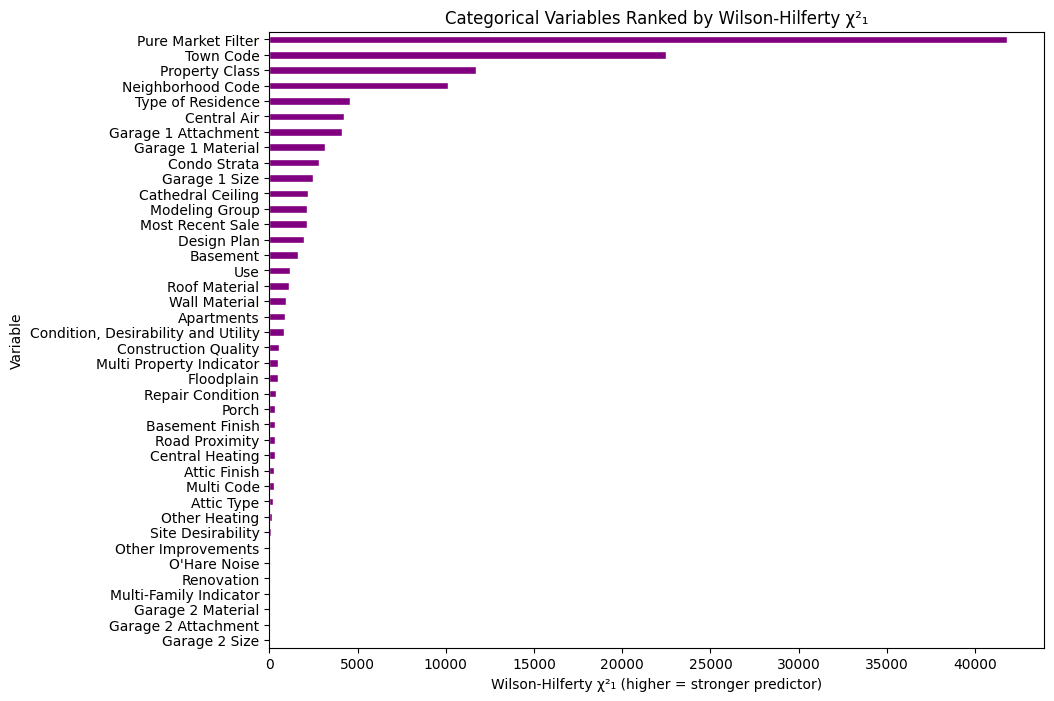

In [327]:
from scipy import stats

def wilson_hilferty(X2, nu):
    if nu <= 1:
        return np.nan

    W1 = (np.sqrt(2 * X2) - np.sqrt(2 * nu - 1) + 1) ** 2 / 2
    W2 = max(0, (7 / 9 + np.sqrt(nu) * ((X2 / nu) ** (1/3) - 1 + 2 / (9 * nu))) ** 3)

    threshold = nu + 10 * np.sqrt(2 * nu)
    if X2 < threshold:
        W = W2
    elif W2 < X2:
        W = (W1 + W2) / 2
    else:
        W = W1
    return W

cat_vars = [
    'Property Class', 'Neighborhood Code', 'Town Code', 'Type of Residence',
    'Apartments', 'Wall Material', 'Roof Material', 'Basement', 'Basement Finish',
    'Central Heating', 'Other Heating', 'Central Air', 'Attic Type', 'Attic Finish',
    'Design Plan', 'Cathedral Ceiling', 'Construction Quality', 'Renovation',
    'Site Desirability', 'Garage 1 Size', 'Garage 1 Material', 'Garage 1 Attachment',
    'Garage 2 Size', 'Garage 2 Material', 'Garage 2 Attachment', 'Porch',
    'Other Improvements', 'Repair Condition', 'Multi Code', 'Multi Property Indicator',
    'Modeling Group', 'Use', 'Condo Class Factor', 'Multi-Family Indicator',
    'Large Lot', 'Condition, Desirability and Utility', "O'Hare Noise", 'Floodplain',
    'Road Proximity', 'Condo Strata', 'Most Recent Sale', 'Pure Market Filter',
]

price_tiers = pd.qcut(df_orig['Sale Price'], q=3, labels=['Low', 'Medium', 'High'])

rows = []
for col in cat_vars:
    if col not in df_orig.columns:
        continue

    sub = pd.DataFrame({col: df_orig[col], 'tier': price_tiers}).dropna()
    if sub[col].nunique() < 2:
        continue
    table = pd.crosstab(sub[col], sub['tier'])

    chi2, pval, dof, _ = stats.chi2_contingency(table)

    wh = wilson_hilferty(chi2, dof)

    rows.append({
        'Variable': col,
        'raw chi2': chi2,
        'df':       dof,
        'chi2_1':   wh,
        'p-value':  pval
    })

chi_df = pd.DataFrame(rows)
chi_df = chi_df.sort_values('chi2_1', ascending=False).reset_index(drop=True)
chi_df['Rank (WH)'] = chi_df.index + 1

fig, ax = plt.subplots(figsize=(10, 8))
chi_ranked = chi_df.set_index('Variable')['chi2_1']
chi_ranked[::-1].plot.barh(ax=ax, color='purple', edgecolor='white')
ax.set_xlabel('Wilson-Hilferty χ²₁ (higher = stronger predictor)')
ax.set_title('Categorical Variables Ranked by Wilson-Hilferty χ²₁')
plt.show()

### 1.2 Wilson-Hilferty $\chi^2$ ranking — binarised-residual target (matches GUIDE)

The tertile ranking above splits Sale Price into three equal-count bins, so the chi-squared has $2(k-1)$ degrees of freedom. Prof. Loh's slides report GUIDE's variable importance as **1-df chi-squared values at the root node** -- i.e. categorical predictor vs. **sign(residual)** at the median.

Below we mirror that: engineer a binary target `sign(Sale Price - median(Sale Price))` and run a $k \times 2$ chi-squared per categorical, giving $(k-1)$ df. Cross-checking the two rankings tests robustness of the result to the choice of target encoding.


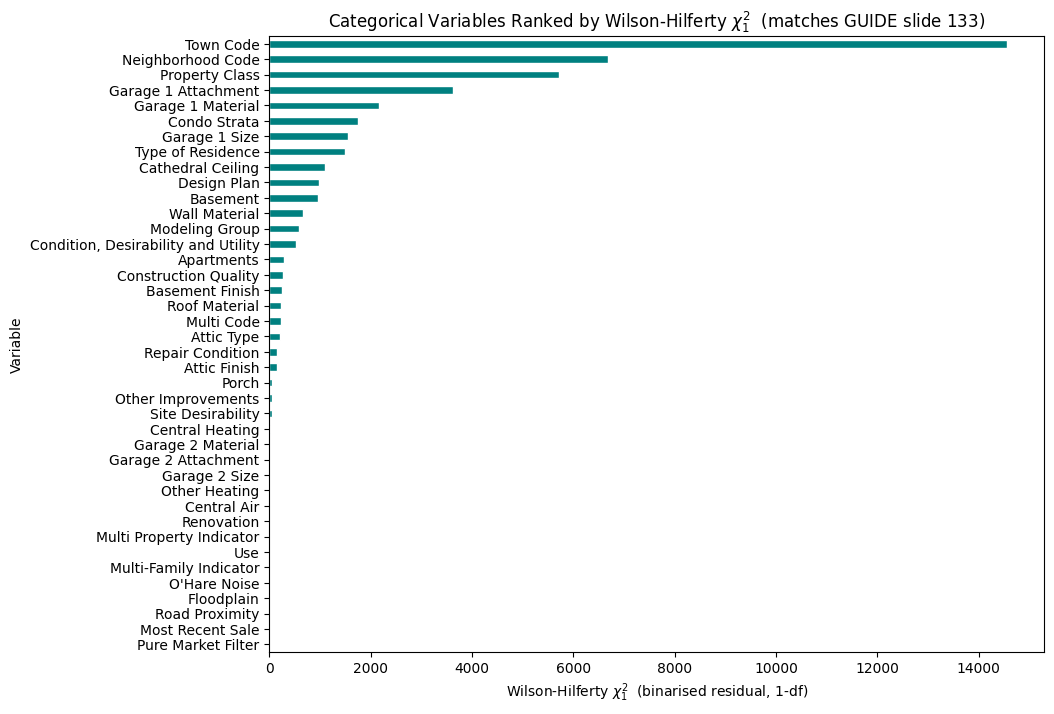

,Variable,Rank (tertile),chi2_1 (tertile),Rank (sign),chi2_1 (sign)
36,Town Code,2,22460.718735,1,14566.776786
24,Neighborhood Code,4,10114.821113,2,6678.358633
29,Property Class,3,11689.563550,3,5715.333638
13,Garage 1 Attachment,7,4122.476351,4,3632.554751
14,Garage 1 Material,8,3164.713873,5,2170.733787
9,Condo Strata,9,2812.317654,6,1759.238969
15,Garage 1 Size,10,2491.899533,7,1548.397261
37,Type of Residence,5,4577.485620,8,1497.346918
5,Cathedral Ceiling,11,2197.403556,9,1092.472689
11,Design Plan,14,1979.237358,10,986.717332


In [328]:
y_full     = df_orig['Sale Price']
resid_sign = (y_full > y_full.median()).astype(int)

rows = []
for col in cat_vars:
    if col not in df_orig.columns:
        continue
    sub = pd.DataFrame({col: df_orig[col], 'sign': resid_sign}).dropna()
    if sub[col].nunique() < 2:
        continue
    table = pd.crosstab(sub[col], sub['sign'])
    chi2, pval, dof, _ = stats.chi2_contingency(table)
    wh = wilson_hilferty(chi2, dof)
    rows.append({
        'Variable': col,
        'raw chi2': chi2,
        'df':       dof,
        'chi2_1':   wh,
        'p-value':  pval,
    })

chi_df_sign = pd.DataFrame(rows).sort_values('chi2_1', ascending=False).reset_index(drop=True)
chi_df_sign['Rank (WH)'] = chi_df_sign.index + 1

fig, ax = plt.subplots(figsize=(10, 8))
chi_df_sign.set_index('Variable')['chi2_1'][::-1].plot.barh(
    ax=ax, color='teal', edgecolor='white')
ax.set_xlabel(r'Wilson-Hilferty $\chi^2_1$  (binarised residual, 1-df)')
ax.set_title(r'Categorical Variables Ranked by Wilson-Hilferty $\chi^2_1$  (matches GUIDE slide 133)')
plt.show()

compare = (chi_df.rename(columns={'chi2_1': 'chi2_1 (tertile)', 'Rank (WH)': 'Rank (tertile)'})
                 .merge(chi_df_sign.rename(columns={'chi2_1': 'chi2_1 (sign)',   'Rank (WH)': 'Rank (sign)'}),
                        on='Variable', how='outer'))
compare = compare[['Variable', 'Rank (tertile)', 'chi2_1 (tertile)',
                   'Rank (sign)',    'chi2_1 (sign)']].sort_values('Rank (sign)')
compare.head(20)


The Wilson-Hilferty ranking puts **Pure Market Filter** far ahead of every other categorical. That is suspicious — let's compare the distribution of `Sale Price` between arm's-length market sales (`Pure Market Filter = 1`) and non-market sales (`Pure Market Filter = 0`) to see why.

df.groupby('Pure Market Filter')['Sale Price'].describe()

In [329]:
market = df_orig[df_orig['Pure Market Filter'] == 1]['Sale Price']
non_market = df_orig[df_orig['Pure Market Filter'] == 0]['Sale Price']

print("Pure Market Filter = 1 (market sales):")
print(f"  Count: {len(market):,}")
print(f"  Mean:   ${market.mean():,.0f}")
print(f"  Median: ${market.median():,.0f}")
print(f"  Min:    ${market.min():,.0f}")
print(f"  Max:    ${market.max():,.0f}")
print()
print("Pure Market Filter = 0 (non-market sales):")
print(f"  Count: {len(non_market):,}")
print(f"  Mean:   ${non_market.mean():,.0f}")
print(f"  Median: ${non_market.median():,.0f}")
print(f"  Min:    ${non_market.min():,.0f}")
print(f"  Max:    ${non_market.max():,.0f}")
print()
print(f"% of non-market sales under $1,000: {(non_market < 1000).sum() / len(non_market) * 100:.1f}%")
print(f"% of market sales under $1,000:     {(market < 1000).sum() / len(market) * 100:.1f}%")



Pure Market Filter = 1 (market sales):
  Count: 80,743
  Mean:   $272,778
  Median: $205,000
  Min:    $10,005
  Max:    $9,400,000

Pure Market Filter = 0 (non-market sales):
  Count: 17,970
  Mean:   $26,695
  Median: $1
  Min:    $0
  Max:    $15,177,429

% of non-market sales under $1,000: 93.7%
% of market sales under $1,000:     0.0%


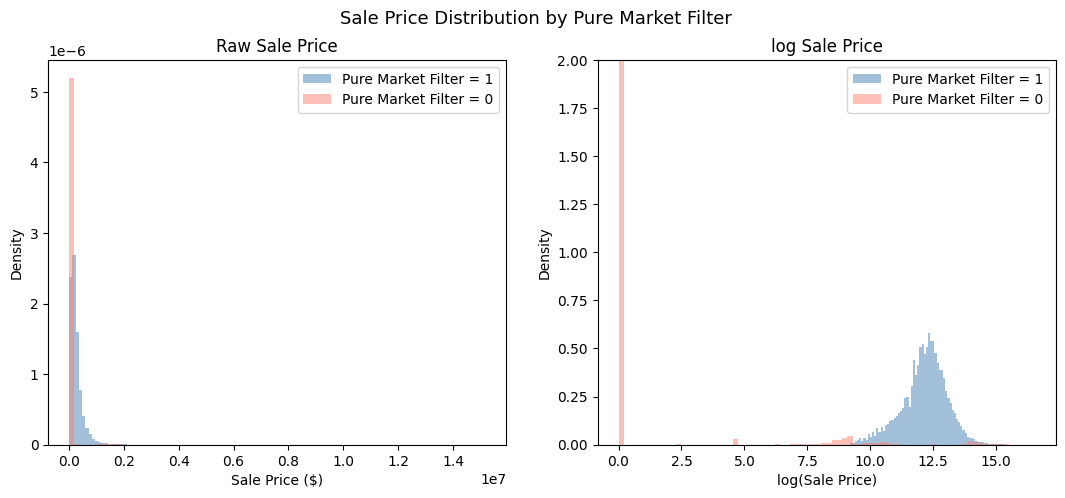

In [330]:
import matplotlib.pyplot as plt
import numpy as np

market = df_orig[df_orig["Pure Market Filter"] == 1]["Sale Price"]
non_market = df_orig[df_orig["Pure Market Filter"] == 0]["Sale Price"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(market, bins=80, alpha=0.5, label="Pure Market Filter = 1", density=True, color="steelblue")
axes[0].hist(non_market, bins=80, alpha=0.5, label="Pure Market Filter = 0", density=True, color="salmon")
axes[0].set_xlabel("Sale Price ($)")
axes[0].set_ylabel("Density")
axes[0].set_title("Raw Sale Price")
axes[0].legend()

m_pos = np.log(market[market > 0])
nm_pos = np.log(non_market[non_market > 0])
axes[1].hist(m_pos, bins=80, alpha=0.5, label="Pure Market Filter = 1", density=True, color="steelblue")
axes[1].hist(nm_pos, bins=80, alpha=0.5, label="Pure Market Filter = 0", density=True, color="salmon")
axes[1].set_ylim(0, 2)
axes[1].set_xlabel("log(Sale Price)")
axes[1].set_ylabel("Density")
axes[1].set_title("log Sale Price")
axes[1].legend()

plt.suptitle("Sale Price Distribution by Pure Market Filter", fontsize=13)
plt.show()


To avoid trivial splits on variables like Pure Market Filter, which would dominate the tree by simply separating real sales from non-market sales, we filter the dataset to keep only genuine market sales (Pure Market Filter = 1) before modeling. This way, tree methods like GUIDE focus on finding what actually drives price differences among real transactions.

### 1.3 Binary-flag audit (Pure Market Filter and other binaries)

The Wilson-Hilferty ranking puts **Pure Market Filter** far ahead of every other categorical. Walk down the WH ranking and look at every binary categorical (exactly 2 distinct non-NA values) in the top 25 to check whether the PMF gap is uniquely extreme.


Binary flags in top-25 WH ranking: ['Pure Market Filter', 'Central Air', 'Most Recent Sale', 'Use', 'Multi Property Indicator', 'Floodplain']



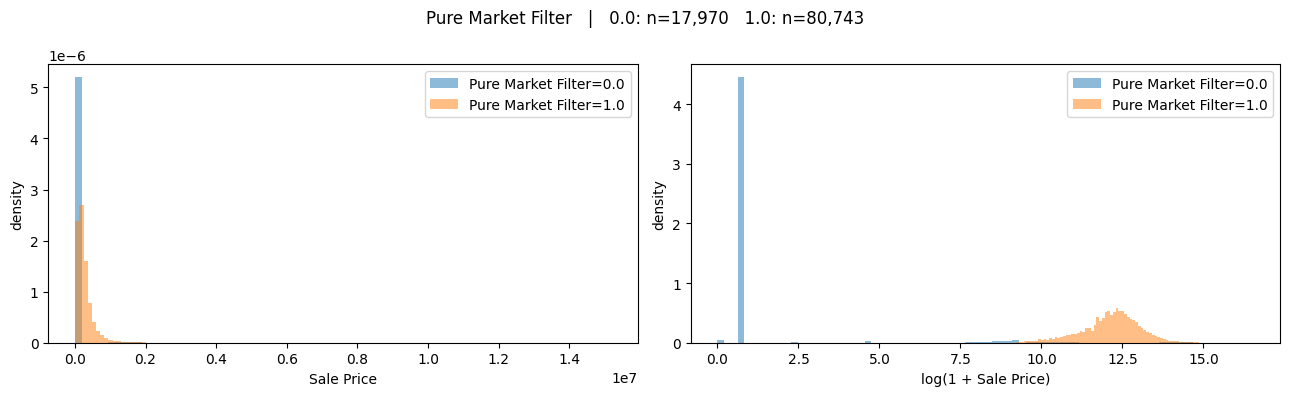

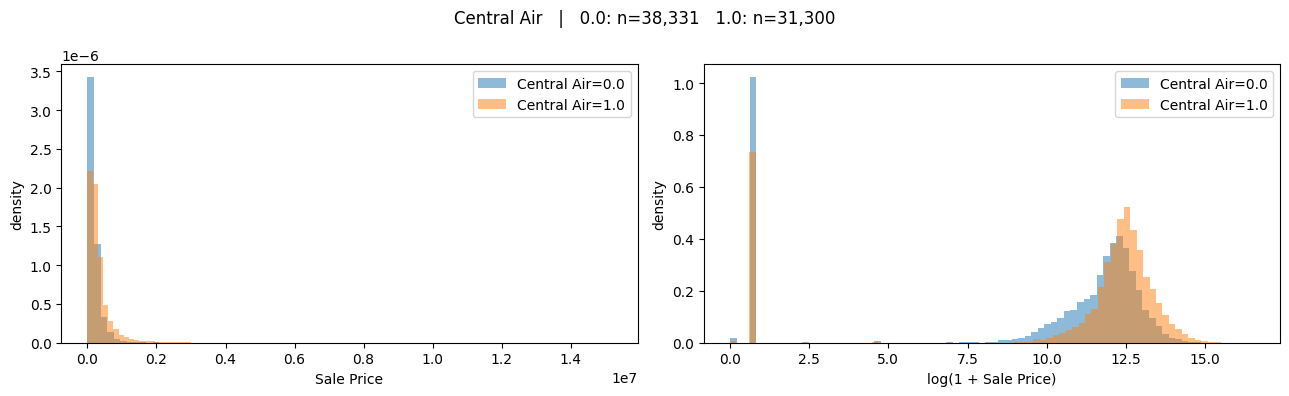

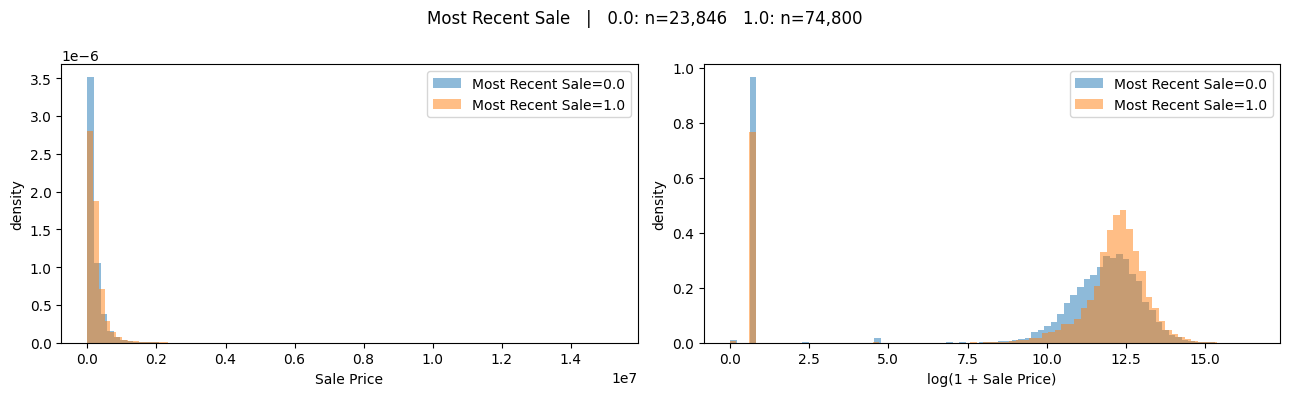

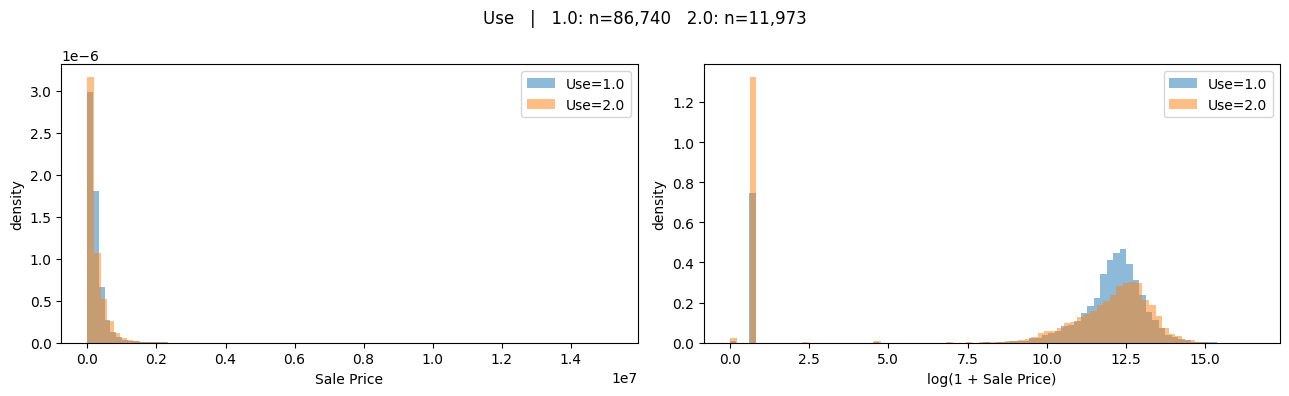

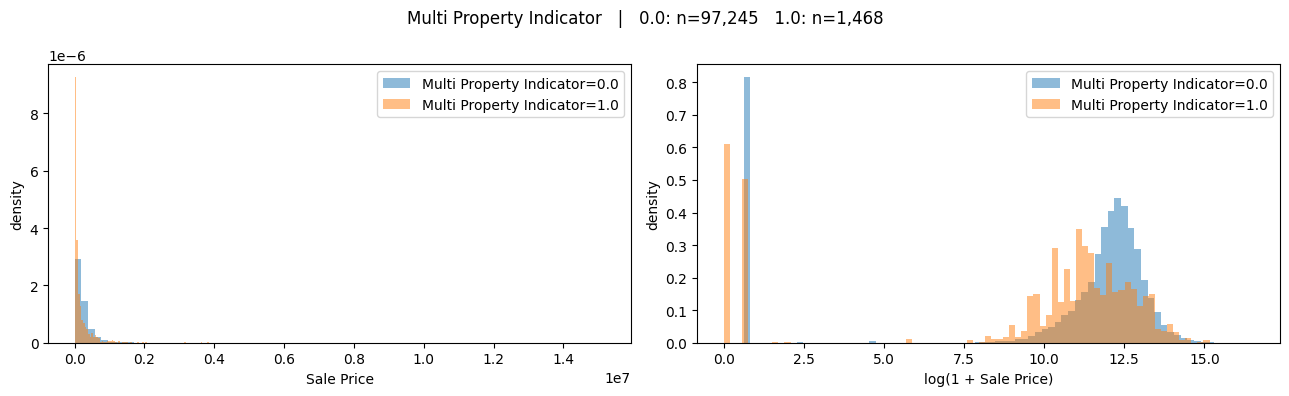

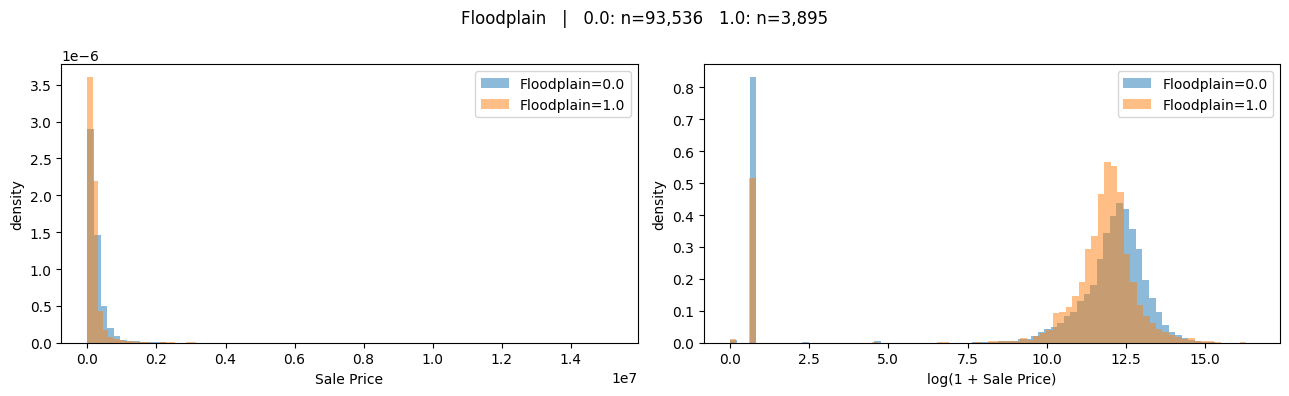

In [331]:
top_k = 25
binary_vars = []
for col in chi_df['Variable'].head(top_k):
    if col not in df_orig.columns:
        continue
    s = df_orig[col].dropna()
    if s.nunique() == 2:
        binary_vars.append(col)

print(f'Binary flags in top-{top_k} WH ranking: {binary_vars}\n')

for col in binary_vars:
    levels = sorted(df_orig[col].dropna().unique())
    g0 = df_orig[df_orig[col] == levels[0]]['Sale Price'].dropna()
    g1 = df_orig[df_orig[col] == levels[1]]['Sale Price'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{col}   |   {levels[0]}: n={len(g0):,}   {levels[1]}: n={len(g1):,}', fontsize=12)

    axes[0].hist(g0, bins=80, alpha=0.5, density=True, label=f'{col}={levels[0]}', color='C0')
    axes[0].hist(g1, bins=80, alpha=0.5, density=True, label=f'{col}={levels[1]}', color='C1')
    axes[0].set_xlabel('Sale Price'); axes[0].set_ylabel('density'); axes[0].legend()

    axes[1].hist(np.log1p(g0), bins=80, alpha=0.5, density=True, label=f'{col}={levels[0]}', color='C0')
    axes[1].hist(np.log1p(g1), bins=80, alpha=0.5, density=True, label=f'{col}={levels[1]}', color='C1')
    axes[1].set_xlabel('log(1 + Sale Price)'); axes[1].set_ylabel('density'); axes[1].legend()

    plt.tight_layout()
    plt.show()


### 1.4 Percentile breakdown per binary flag (data quality vs signal)


In [332]:
for col in binary_vars:
    print(df_orig.groupby(col)['Sale Price'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


                      count           mean            std      min       1%  \
Pure Market Filter                                                            
0.0                 17970.0   26695.295826  311237.948900      0.0      1.0   
1.0                 80743.0  272777.858143  283712.327285  10005.0  17000.0   

                         5%       50%       95%        99%         max  
Pure Market Filter                                                      
0.0                     1.0       1.0    6000.0  1143100.0  15177429.0  
1.0                 35000.0  205000.0  725000.0  1375000.0   9400000.0  
               count           mean            std  min   1%   5%       50%  \
Central Air                                                                   
0.0          38331.0  173294.514518  231325.480848  0.0  1.0  1.0  125000.0   
1.0          31300.0  312603.438498  390373.572947  0.0  1.0  1.0  229000.0   

                  95%        99%         max  
Central Air                

In [333]:
df = df_orig[df_orig["Pure Market Filter"] == 1].copy()
df

,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Type of Residence,Apartments,Wall Material,Roof Material,Rooms,...,Age Decade Squared,Lot Size Squared,Improvement Size Squared,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Square root of lot size,Square root of age,Square root of improvement size,Town and Neighborhood
0,17273100931118,299,40,365398.0,76,NaN,NaN,NaN,NaN,NaN,...,19.36,1.335157e+11,NaN,1.0,NaN,40.0,604.481596,6.633250,NaN,7640.0
1,18013090421010,299,52,19551.0,21,NaN,NaN,NaN,NaN,NaN,...,32.49,3.822416e+08,NaN,1.0,NaN,52.0,139.824890,7.549834,NaN,2152.0
2,16094150130000,211,13,4500.0,77,3.0,6.0,2.0,2.0,24.0,...,75.69,2.025000e+07,55279225.0,1.0,1.0,13.0,67.082039,9.327379,86.226446,7713.0
3,12253140491007,299,80,12148.0,20,NaN,NaN,NaN,NaN,NaN,...,6.76,1.475739e+08,NaN,1.0,NaN,80.0,110.217966,5.099020,NaN,2080.0
4,12111190201042,299,390,48470.0,71,NaN,NaN,NaN,NaN,NaN,...,20.25,2.349341e+09,NaN,1.0,NaN,390.0,220.159033,6.708204,NaN,71390.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98705,18032090470000,202,42,4725.0,21,1.0,0.0,2.0,1.0,4.0,...,40.96,2.232562e+07,746496.0,1.0,1.0,42.0,68.738635,8.000000,29.393877,2142.0
98706,2121000301044,299,70,214881.0,29,NaN,NaN,NaN,NaN,NaN,...,13.69,4.617384e+10,NaN,1.0,NaN,70.0,463.552586,6.082763,NaN,2970.0
98708,14084070221155,299,60,81075.0,73,NaN,NaN,NaN,NaN,NaN,...,60.84,6.573156e+09,NaN,1.0,NaN,60.0,284.736720,8.831761,NaN,7360.0
98710,5341170251014,299,93,27554.0,23,NaN,NaN,NaN,NaN,NaN,...,2.25,7.592229e+08,NaN,1.0,NaN,93.0,165.993976,3.872983,NaN,2393.0


Next, we will filter out all columns that are mathematically computed from other columns.

Note: I have been able to propose these derivations via speculation through the "About Dataset" section.

1) `Age Squared`, `Age Decade`, and `Age Decade Squared` can be derived mathematically from `Age`.

2) `Lot Size Squared` and `Square root of lot size` can be derived from `Land Square Feet`.

3) `Improvement Size Squared` and `Square root of improvement size` can be derived from `Building Square Feet`.

4) `Square root of age` can be derived from `Age`.

5) `Town and Neighborhood` is a concatenation of `Town Code` and `Neighborhood Code`.

6) `Neigborhood Code (mapping)` is a copy of `Neighborhood Code`.

7) `Sale Quarter`, `Sale Half-Year`, `Sale Half of Year`, `Sale Quarter of Year`, and `Sale Month of Year` are all derived from `Sale Date`. We keep `Sale Year` and `Sale Date` and drop the rest.

8) `Garage Indicator` is derived from `Garage 1 Size` (1 if a garage exists, 0 otherwise).

Since the original columns are already in the dataset, keeping these transforms adds more redundancy without increasing the accuracy of regression predictions.

### 1.5 Validating that derived columns are mathematical functions of base columns

For example, `Age Squared = Age^2`, `Lot Size Squared = Land Square Feet^2`, etc. Verifying these lets us drop the derived columns without information loss.


In [334]:
idx = df["Age Squared"].dropna().index
print("Age Squared == Age^2:",
      (df["Age Squared"][idx] == df["Age"][idx]**2).all())

idx = df["Age Decade"].dropna().index
print("Age Decade == Age/10:",
      (df["Age Decade"][idx] == df["Age"][idx]/10).all())

idx = df["Age Decade Squared"].dropna().index
print("Age Decade Squared ≈ (Age/10)^2:",
      (df["Age Decade Squared"][idx].round(2) == ((df["Age"][idx]/10)**2).round(2)).all())

idx = df["Square root of age"].dropna().index
print("Square root of age ≈ sqrt(Age):",
      (df["Square root of age"][idx].round(5) == np.sqrt(df["Age"][idx]).round(5)).all())

idx = df["Lot Size Squared"].dropna().index
print("Lot Size Squared ≈ Land Square Feet^2:",
      (df["Lot Size Squared"][idx].round(0) == (df["Land Square Feet"][idx]**2).round(0)).all())

idx = df["Square root of lot size"].dropna().index
print("Square root of lot size ≈ sqrt(Land Square Feet):",
      (df["Square root of lot size"][idx].round(5) == np.sqrt(df["Land Square Feet"][idx]).round(5)).all())

idx = df["Improvement Size Squared"].dropna().index
print("Improvement Size Squared == Building Square Feet^2:",
      (df["Improvement Size Squared"][idx] == df["Building Square Feet"][idx]**2).all())

idx = df["Square root of improvement size"].dropna().index
print("Square root of improvement size ≈ sqrt(Building Square Feet):",
      (df["Square root of improvement size"][idx].round(5) == np.sqrt(df["Building Square Feet"][idx]).round(5)).all())

idx = df["Neigborhood Code (mapping)"].dropna().index
print("Neigborhood Code (mapping) == Neighborhood Code:",
      (df["Neigborhood Code (mapping)"][idx] == df["Neighborhood Code"][idx]).all())

idx = df["Town and Neighborhood"].dropna().index
derived = (df["Town Code"][idx].astype(int).astype(str) + df["Neighborhood Code"][idx].astype(int).astype(str)).astype(float)
print("Town and Neighborhood == concat(Town Code, Neighborhood Code):",
      (df["Town and Neighborhood"][idx] == derived).all())

idx = df["Garage Indicator"].dropna().index
print("Garage Indicator == (Garage 1 Size != 0):",
      (df["Garage Indicator"][idx] == (df["Garage 1 Size"][idx] != 0).astype(float)).all())


Age Squared == Age^2: True
Age Decade == Age/10: True
Age Decade Squared ≈ (Age/10)^2: True
Square root of age ≈ sqrt(Age): True
Lot Size Squared ≈ Land Square Feet^2: True
Square root of lot size ≈ sqrt(Land Square Feet): True
Improvement Size Squared == Building Square Feet^2: True
Square root of improvement size ≈ sqrt(Building Square Feet): True
Neigborhood Code (mapping) == Neighborhood Code: True
Town and Neighborhood == concat(Town Code, Neighborhood Code): True
Garage Indicator == (Garage 1 Size != 0): True


In [335]:
derived_cols = [

    'Age Squared', 'Age Decade', 'Age Decade Squared', 'Square root of age',

    'Lot Size Squared', 'Square root of lot size',

    'Improvement Size Squared', 'Square root of improvement size',

    'Neigborhood Code (mapping)', 'Town and Neighborhood',

    'Sale Quarter', 'Sale Half-Year', 'Sale Half of Year',
    'Sale Quarter of Year', 'Sale Month of Year',

    'Garage Indicator',

    'Pure Market Filter',
]

df = df.drop(columns=derived_cols)
print(f"After dropping derived columns: {df.shape[0]} rows, {df.shape[1]} columns")

df

After dropping derived columns: 80743 rows, 66 columns


,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Type of Residence,Apartments,Wall Material,Roof Material,Rooms,...,Condo Class Factor,Multi-Family Indicator,Large Lot,"Condition, Desirability and Utility",O'Hare Noise,Floodplain,Road Proximity,Condo Strata,Sale Year,Most Recent Sale
0,17273100931118,299,40,365398.0,76,NaN,NaN,NaN,NaN,NaN,...,299.0,NaN,NaN,NaN,0.0,0.0,1.0,NaN,2015.0,1.0
1,18013090421010,299,52,19551.0,21,NaN,NaN,NaN,NaN,NaN,...,299.0,NaN,NaN,NaN,0.0,0.0,1.0,1.0,2018.0,1.0
2,16094150130000,211,13,4500.0,77,3.0,6.0,2.0,2.0,24.0,...,NaN,211.0,NaN,NaN,0.0,0.0,0.0,NaN,2014.0,1.0
3,12253140491007,299,80,12148.0,20,NaN,NaN,NaN,NaN,NaN,...,299.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2013.0,1.0
4,12111190201042,299,390,48470.0,71,NaN,NaN,NaN,NaN,NaN,...,299.0,NaN,NaN,NaN,1.0,0.0,0.0,2.0,2018.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98705,18032090470000,202,42,4725.0,21,1.0,0.0,2.0,1.0,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2016.0,1.0
98706,2121000301044,299,70,214881.0,29,NaN,NaN,NaN,NaN,NaN,...,299.0,NaN,NaN,NaN,0.0,0.0,1.0,NaN,2017.0,1.0
98708,14084070221155,299,60,81075.0,73,NaN,NaN,NaN,NaN,NaN,...,299.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2017.0,0.0
98710,5341170251014,299,93,27554.0,23,NaN,NaN,NaN,NaN,NaN,...,299.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2013.0,1.0


### 1.6 Dropping uninformative identifier columns

`PIN`, `Deed No.`, and `Property Address` are identifiers, not predictors -- their geographic content is already captured by `Neighborhood Code`, `Town Code`, `Census Tract`, `Longitude`, `Latitude`.


In [336]:
id_cols = ['PIN', 'Deed No.', 'Property Address']
df = df.drop(columns=id_cols)
print(f"After dropping identifiers: {df.shape[0]} rows, {df.shape[1]} columns")

After dropping identifiers: 80743 rows, 63 columns


In [337]:
continuous_cols = ['Sale Price', 'Land Square Feet', 'Building Square Feet',
                   'Age', 'Rooms', 'Bedrooms', 'Full Baths', 'Half Baths',
                   'Fireplaces', 'Apartments', 'Longitude', 'Latitude']

skewness = df[continuous_cols].skew().sort_values(ascending=False)
print("Skewness for continuous columns:")
print(skewness.to_string())


Skewness for continuous columns:
Land Square Feet        7.556093
Sale Price              5.296046
Rooms                   3.566931
Bedrooms                3.345441
Apartments              2.966069
Building Square Feet    2.775936
Full Baths              2.116920
Fireplaces              1.521311
Half Baths              1.111558
Age                     0.309562
Latitude               -0.506481
Longitude              -1.068875


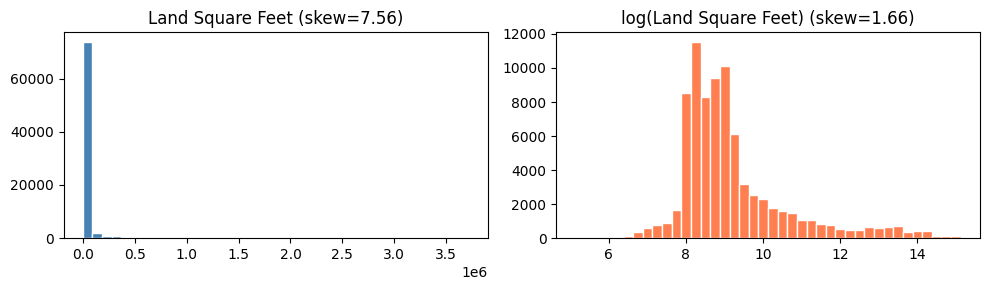

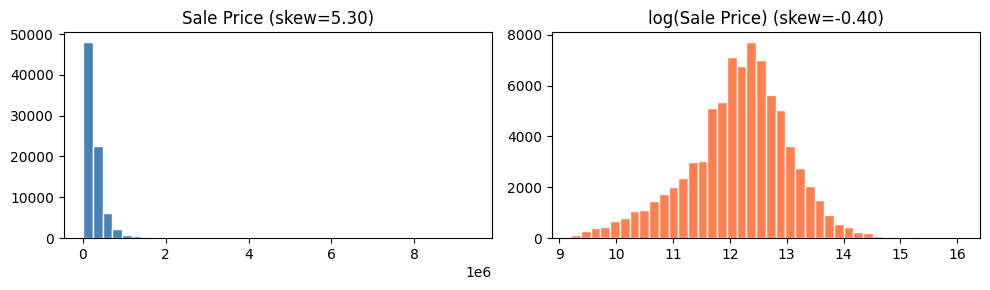

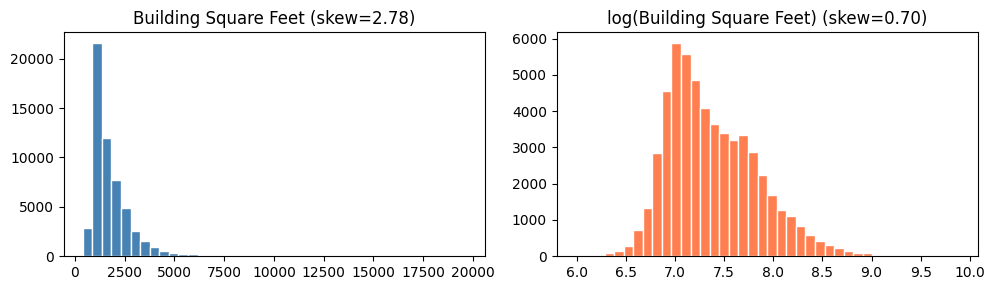

In [338]:
top_skewed = ['Land Square Feet', 'Sale Price', 'Building Square Feet']

for col in top_skewed:

    data = df[col].dropna()
    data_pos = data[data > 0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

    ax1.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax1.set_title(f"{col} (skew={data.skew():.2f})")

    ax2.hist(np.log(data_pos), bins=40, color='coral', edgecolor='white')
    ax2.set_title(f"log({col}) (skew={np.log(data_pos).skew():.2f})")

    plt.tight_layout()
    plt.show()

### 1.7 Sale Price over time

We check whether Sale Price drifts over time -- a steady trend would mean `Sale Year` carries meaningful signal that GUIDE (and downstream methods) should pick up. Median is used because of the heavy right skew.


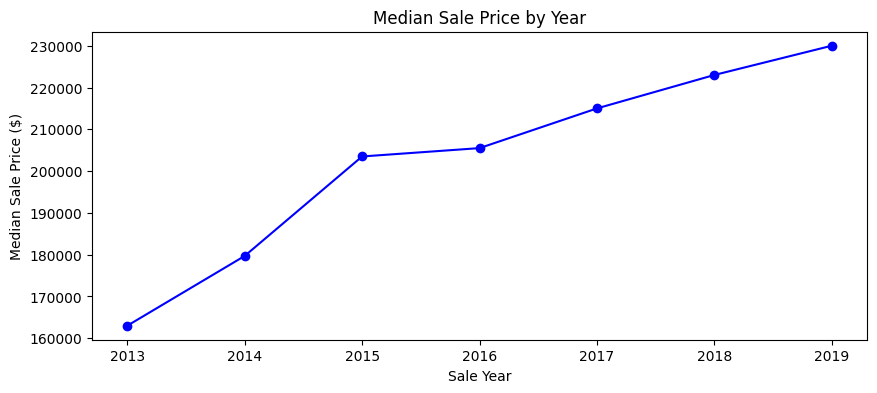

In [339]:
yearly_median = df.groupby('Sale Year')['Sale Price'].median()

fig, ax = plt.subplots(figsize=(10, 4))
yearly_median.plot(ax=ax, marker='o', color='blue')
ax.set_xlabel('Sale Year')
ax.set_ylabel('Median Sale Price ($)')
ax.set_title('Median Sale Price by Year')
plt.show()


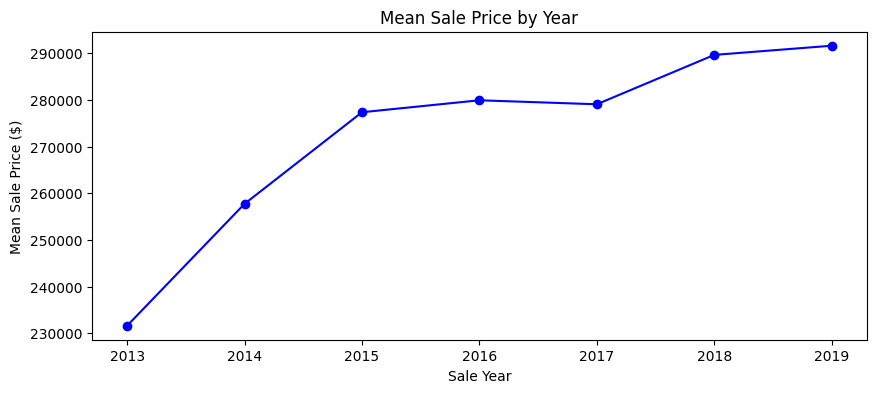

In [340]:
yearly_median = df.groupby('Sale Year')['Sale Price'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
yearly_median.plot(ax=ax, marker='o', color='blue')
ax.set_xlabel('Sale Year')
ax.set_ylabel('Mean Sale Price ($)')
ax.set_title('Mean Sale Price by Year')
plt.show()

Removing the assessor's own price predictions for the land and building according to the online website:

1) `Estimate (Building)`: "Board of Review final estimated market value of building from the prior tax year." This is the county's own valuation of the structure.

2) `Estimate (Land)`: "Board of Review final estimated market value of land from the prior tax year."

In [341]:
df = df.drop(columns=['Estimate (Land)', 'Estimate (Building)'])

corr = df.select_dtypes(include='number').corr()
sale_corr = corr['Sale Price'].drop('Sale Price').abs().sort_values(ascending=False)

print("Top 15 predictors correlated with Sale Price:")
print(sale_corr.head(15).to_string())

Top 15 predictors correlated with Sale Price:
Condo Strata                  0.741737
Building Square Feet          0.513483
Full Baths                    0.448408
Fireplaces                    0.422707
Percent Ownership             0.332603
Rooms                         0.296493
Latitude                      0.279491
Bedrooms                      0.268628
Half Baths                    0.259785
Roof Material                 0.244780
Central Air                   0.224660
Renovation                    0.219586
Cathedral Ceiling             0.209854
Design Plan                   0.195847
Total Building Square Feet    0.186084


### 1.9 Correlation heatmap of top numerical predictors

Heatmap of the top 10 predictors most correlated with Sale Price, showing pairwise correlations. Reveals multicollinearity (problematic for linear regression but not for tree methods).


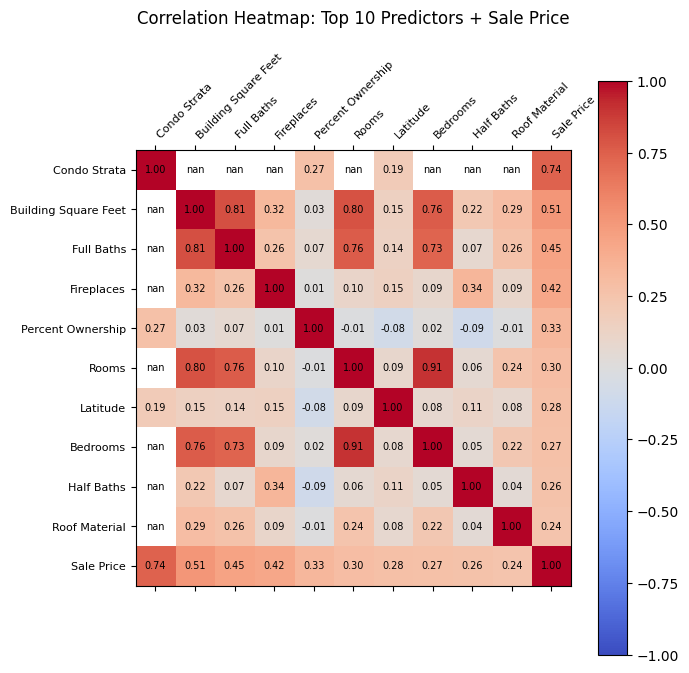

In [342]:
top10 = sale_corr.head(10).index.tolist()
cols = top10 + ['Sale Price']
matrix = df[cols].corr().values

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.matshow(matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='left', fontsize=8)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=8)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{matrix[i,j]:.2f}", ha='center', va='center', fontsize=7)

ax.set_title("Correlation Heatmap: Top 10 Predictors + Sale Price", pad=20)
plt.colorbar(im)
plt.tight_layout()
plt.show()

### 1.10 Highly correlated predictor pairs ($|r| > 0.8$)

Flag all pairs of variables with high mutual correlation. Highly correlated pairs are expected to receive similar GUIDE chi-squared scores and to land at similar tree depths.


In [343]:
THRESHOLD = 0.8

numeric_df = df.select_dtypes(include='number').drop(columns=['Sale Price'], errors='ignore')
corr_matrix = numeric_df.corr()

pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > THRESHOLD:
            pairs.append({'Var 1': cols[i], 'Var 2': cols[j], 'r': r})

pairs_df = pd.DataFrame(pairs)
pairs_df


,Var 1,Var 2,r
0,Property Class,Multi-Family Indicator,1.000000
1,Apartments,Use,0.876483
2,Rooms,Bedrooms,0.905522
3,Rooms,Building Square Feet,0.802544
4,Renovation,Garage 2 Area,1.000000
5,Garage 1 Attachment,Garage 1 Area,0.854652
6,Garage 2 Size,Garage 2 Material,-0.905621
7,Garage 2 Size,Garage 2 Attachment,-0.909876
8,Garage 2 Material,Garage 2 Attachment,0.920190
9,Building Square Feet,Full Baths,0.809094


### 1.11 Missing-value analysis

Bar chart of percent-missing for every column with at least one `NaN`. Columns with very high missingness may need to be dropped; moderate missingness can be imputed.


**Why are values missing?** Most missingness falls into two groups:

1. **Property Class 299** (condos, vacant land) — these records lack structural characteristics entirely 
(e.g. `Type of Residence`, `Rooms`, `Bedrooms`, `Wall Material`, `Building Square Feet`). 
This is by design: the assessor's NCHARS modeling group excludes these fields.

2. **Optional amenities** — fields like `Fireplaces`, `Garage 1 Size`, `Attic Type`, `Cathedral Ceiling`, 
and `Half Baths` are `NaN` when the property simply does not have that feature.

Below we check whether the presence/absence of high-missingness features is associated with 
meaningful Sale Price differences, to decide whether to drop or impute.

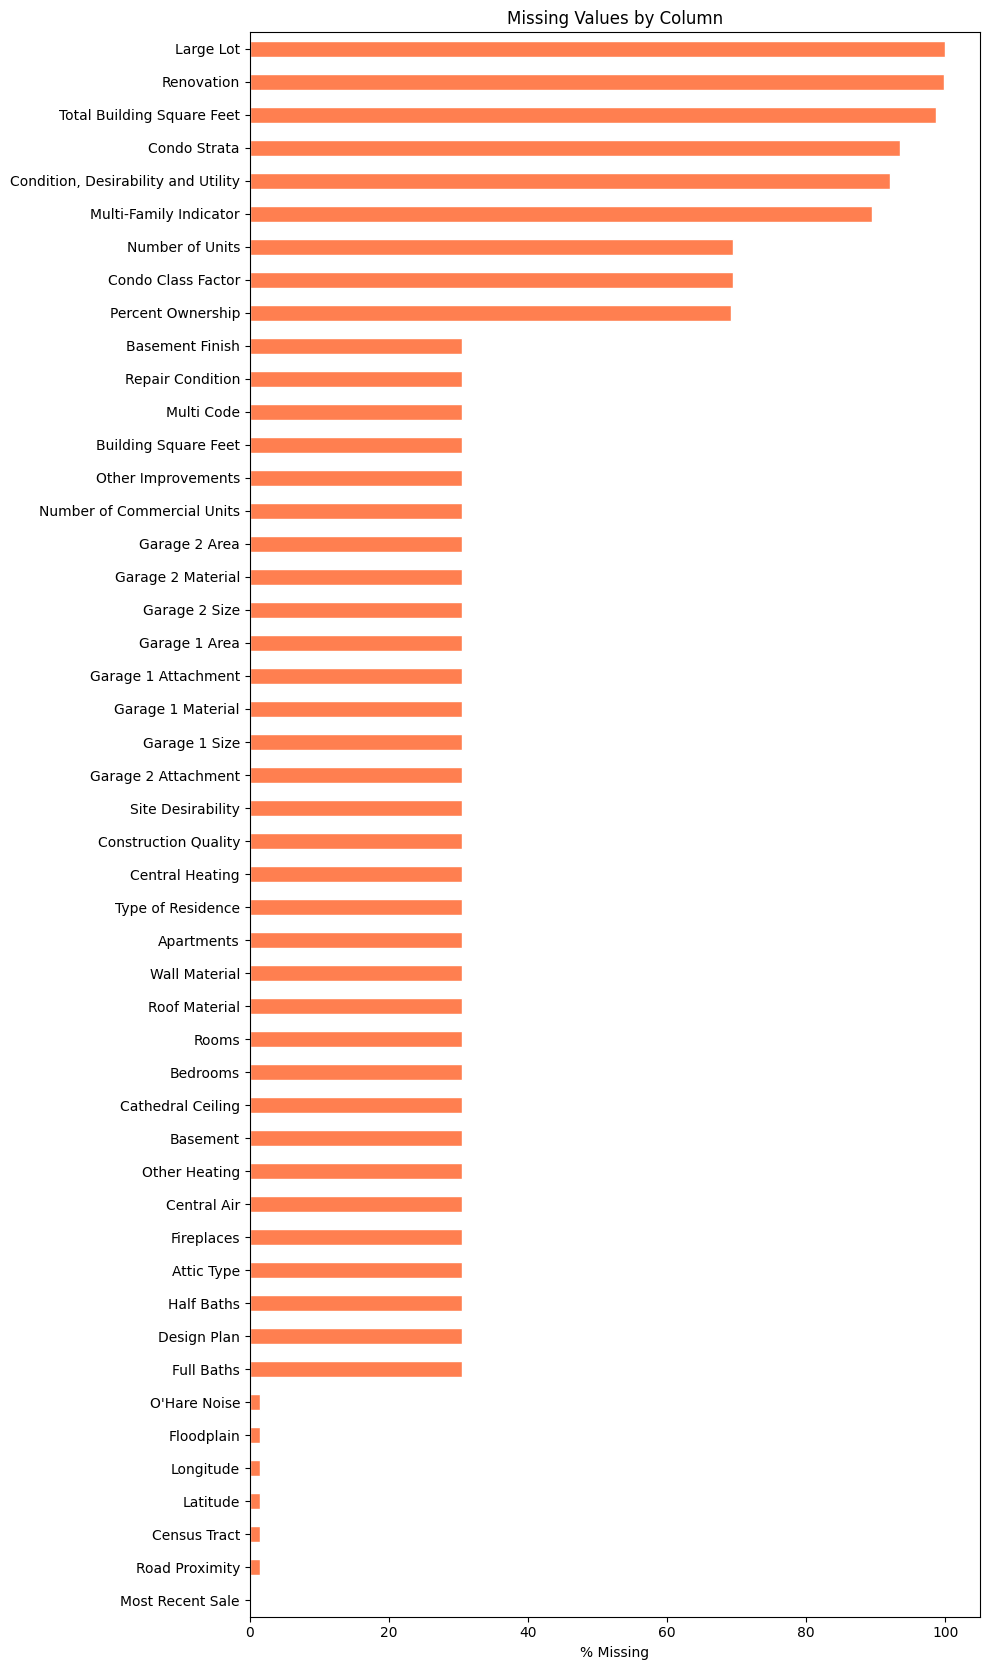


Columns with missing values: 48
Large Lot                              100.000000
Renovation                              99.869958
Total Building Square Feet              98.617837
Condo Strata                            93.426056
Condition, Desirability and Utility     92.107056
Multi-Family Indicator                  89.475249
Number of Units                         69.422736
Condo Class Factor                      69.422736
Percent Ownership                       69.254301
Basement Finish                         30.578502
Repair Condition                        30.577264
Multi Code                              30.577264
Building Square Feet                    30.577264
Other Improvements                      30.577264
Number of Commercial Units              30.577264
Garage 2 Area                           30.577264
Garage 2 Material                       30.577264
Garage 2 Size                           30.577264
Garage 1 Area                           30.577264
Garage 1 Attachme

In [344]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) == 0:
    print('No missing values found in the dataset after cleaning.')
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_pct) * 0.35)))
    missing_pct.plot.barh(ax=ax, color='coral', edgecolor='white')
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Values by Column')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(f'\nColumns with missing values: {len(missing_pct)}')
    print(missing_pct.to_string())

In [345]:

high_miss = missing_pct[missing_pct > 5].index.tolist()

results = []
for col in high_miss:
    present = df.loc[df[col].notna(), 'Sale Price']
    absent  = df.loc[df[col].isna(),  'Sale Price']
    results.append({
        'Column': col,
        '% Missing': f"{df[col].isna().mean()*100:.1f}%",
        'Median (present)': f"${present.median():,.0f}",
        'Median (absent)':  f"${absent.median():,.0f}",
        'N present': len(present),
        'N absent':  len(absent)
    })

pd.DataFrame(results).set_index('Column')


,% Missing,Median (present),Median (absent),N present,N absent
Column,,,,,
Large Lot,100.0%,$nan,"$205,000",0,80743
Renovation,99.9%,"$550,000","$205,000",105,80638
Total Building Square Feet,98.6%,"$96,520","$205,000",1116,79627
Condo Strata,93.4%,"$175,000","$208,000",5308,75435
"Condition, Desirability and Utility",92.1%,"$225,000","$202,000",6373,74370
Multi-Family Indicator,89.5%,"$225,000","$202,000",8498,72245
Number of Units,69.4%,"$181,500","$215,000",24689,56054
Condo Class Factor,69.4%,"$181,500","$215,000",24689,56054
Percent Ownership,69.3%,"$181,000","$215,000",24825,55918


### 1.12 Structural missingness by Modeling Group

Many features are intentionally null for certain property types (e.g. condos in NCHARS don't have `Wall Material` or `Rooms`). Breaking down `% missing per feature x Modeling Group` makes these structural patterns visible. GUIDE handles them natively without imputation -- a key advantage over linear regression / random forest.


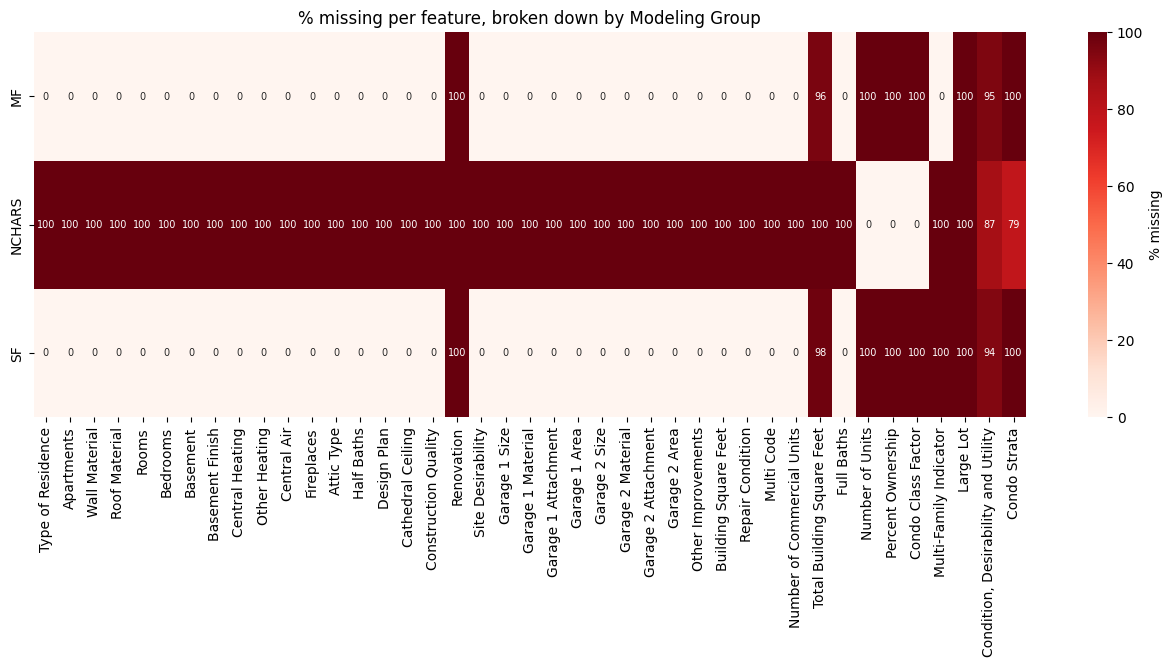

In [346]:
import seaborn as sns

group_col = 'Modeling Group'

rows = {}
for g in sorted(df[group_col].dropna().unique()):
    subset = df[df[group_col] == g]
    rows[g] = subset.isna().mean() * 100

miss_by_group = pd.DataFrame(rows).T
miss_by_group = miss_by_group.loc[:, miss_by_group.max() > 5]
miss_by_group = miss_by_group.drop(columns=['Sale Price', group_col], errors='ignore')

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(miss_by_group, annot=True, fmt='.0f', cmap='Reds',
            vmin=0, vmax=100, cbar_kws={'label': '% missing'},
            annot_kws={'size': 7}, ax=ax)
ax.set_title('% missing per feature, broken down by Modeling Group')
plt.show()


### 1.13 ANOVA F-statistic ranking of categorical predictors

For each categorical, compute ANOVA F (between-group vs within-group Sale Price variance) and divide by the number of categories to keep the comparison fair across cardinalities. Higher = better separation of Sale Price.


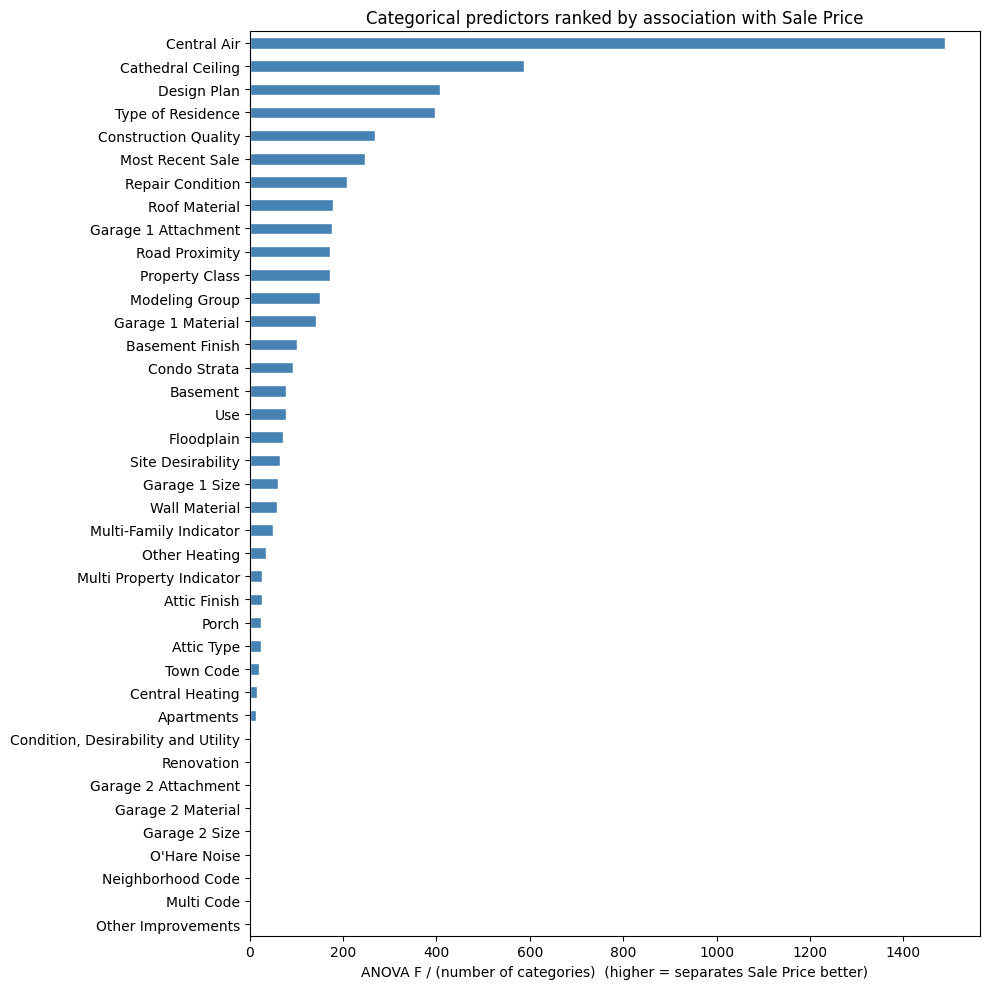

In [347]:
from scipy import stats

cat_vars = [
    'Property Class', 'Neighborhood Code', 'Town Code', 'Type of Residence',
    'Apartments', 'Wall Material', 'Roof Material', 'Basement', 'Basement Finish',
    'Central Heating', 'Other Heating', 'Central Air', 'Attic Type', 'Attic Finish',
    'Design Plan', 'Cathedral Ceiling', 'Construction Quality', 'Renovation',
    'Site Desirability', 'Garage 1 Size', 'Garage 1 Material', 'Garage 1 Attachment',
    'Garage 2 Size', 'Garage 2 Material', 'Garage 2 Attachment', 'Porch',
    'Other Improvements', 'Repair Condition', 'Multi Code', 'Multi Property Indicator',
    'Modeling Group', 'Use', 'Condo Class Factor', 'Multi-Family Indicator',
    'Large Lot', 'Condition, Desirability and Utility', "O'Hare Noise", 'Floodplain',
    'Road Proximity', 'Condo Strata', 'Most Recent Sale'
]
cat_vars = [c for c in cat_vars if c in df.columns]
f_scores = {}

for col in cat_vars:

    groups = []
    for category, group in df.groupby(col):
        prices = group['Sale Price'].dropna()
        if len(prices) > 1:
            groups.append(prices)

    if len(groups) < 2:
        continue

    F, _ = stats.f_oneway(*groups)
    f_scores[col] = F / len(groups)

ranked = pd.Series(f_scores).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
ranked[::-1].plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('ANOVA F / (number of categories)  (higher = separates Sale Price better)')
ax.set_title('Categorical predictors ranked by association with Sale Price')

plt.tight_layout()
plt.show()


**Low-cardinality version — boxplot candidates.** The ranking above mixes variables
with very different numbers of categories, but high-cardinality variables (like
`Neighborhood Code` with ~100 levels) make for unreadable boxplots. Below we repeat
the same normalised-F ranking, but restricted to categorical columns with **fewer
than 20 levels**. The top of this chart is where drilling-down with boxplots or
category-level rankings is most useful.


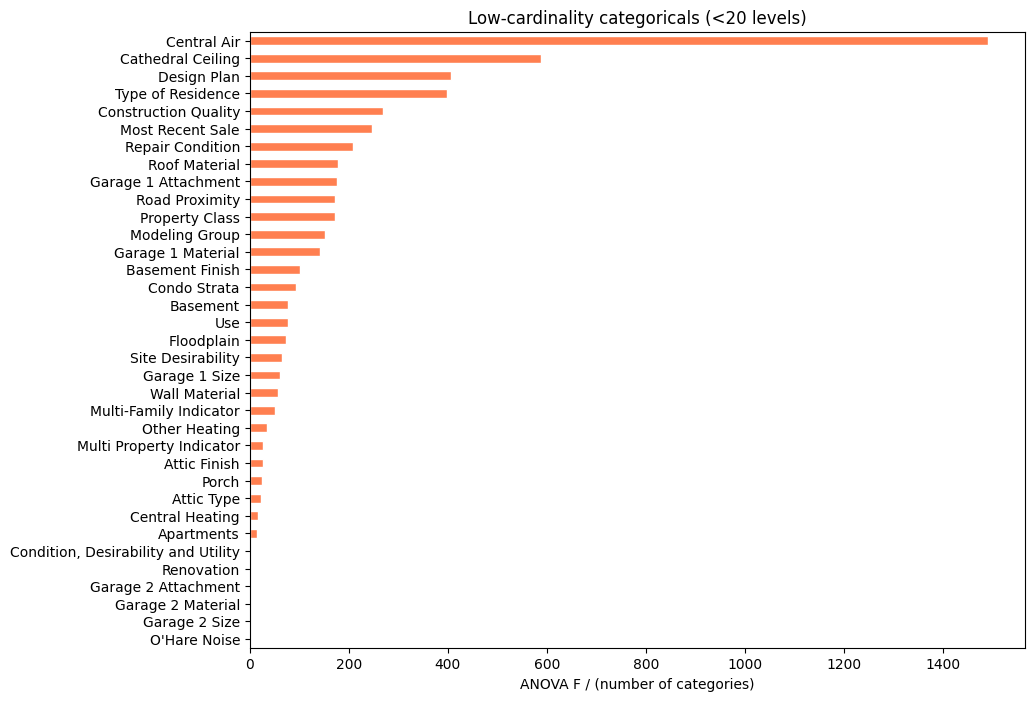

In [348]:
cat_vars_small = [c for c in cat_vars if df[c].nunique() < 20]

f_scores_small = {}
for col in cat_vars_small:
    groups = []
    for category, group in df.groupby(col):
        prices = group['Sale Price'].dropna()
        if len(prices) > 1:
            groups.append(prices)

    if len(groups) < 2:
        continue

    F, _ = stats.f_oneway(*groups)
    f_scores_small[col] = F / len(groups)

ranked_small = pd.Series(f_scores_small).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ranked_small[::-1].plot.barh(ax=ax, color='coral', edgecolor='white')
ax.set_xlabel('ANOVA F / (number of categories)')
ax.set_title('Low-cardinality categoricals (<20 levels)')

plt.show()

Wilson-Hilferty top 3: ['Property Class', 'Type of Residence', 'Central Air']
ANOVA F top 3:         ['Central Air', 'Cathedral Ceiling', 'Design Plan']


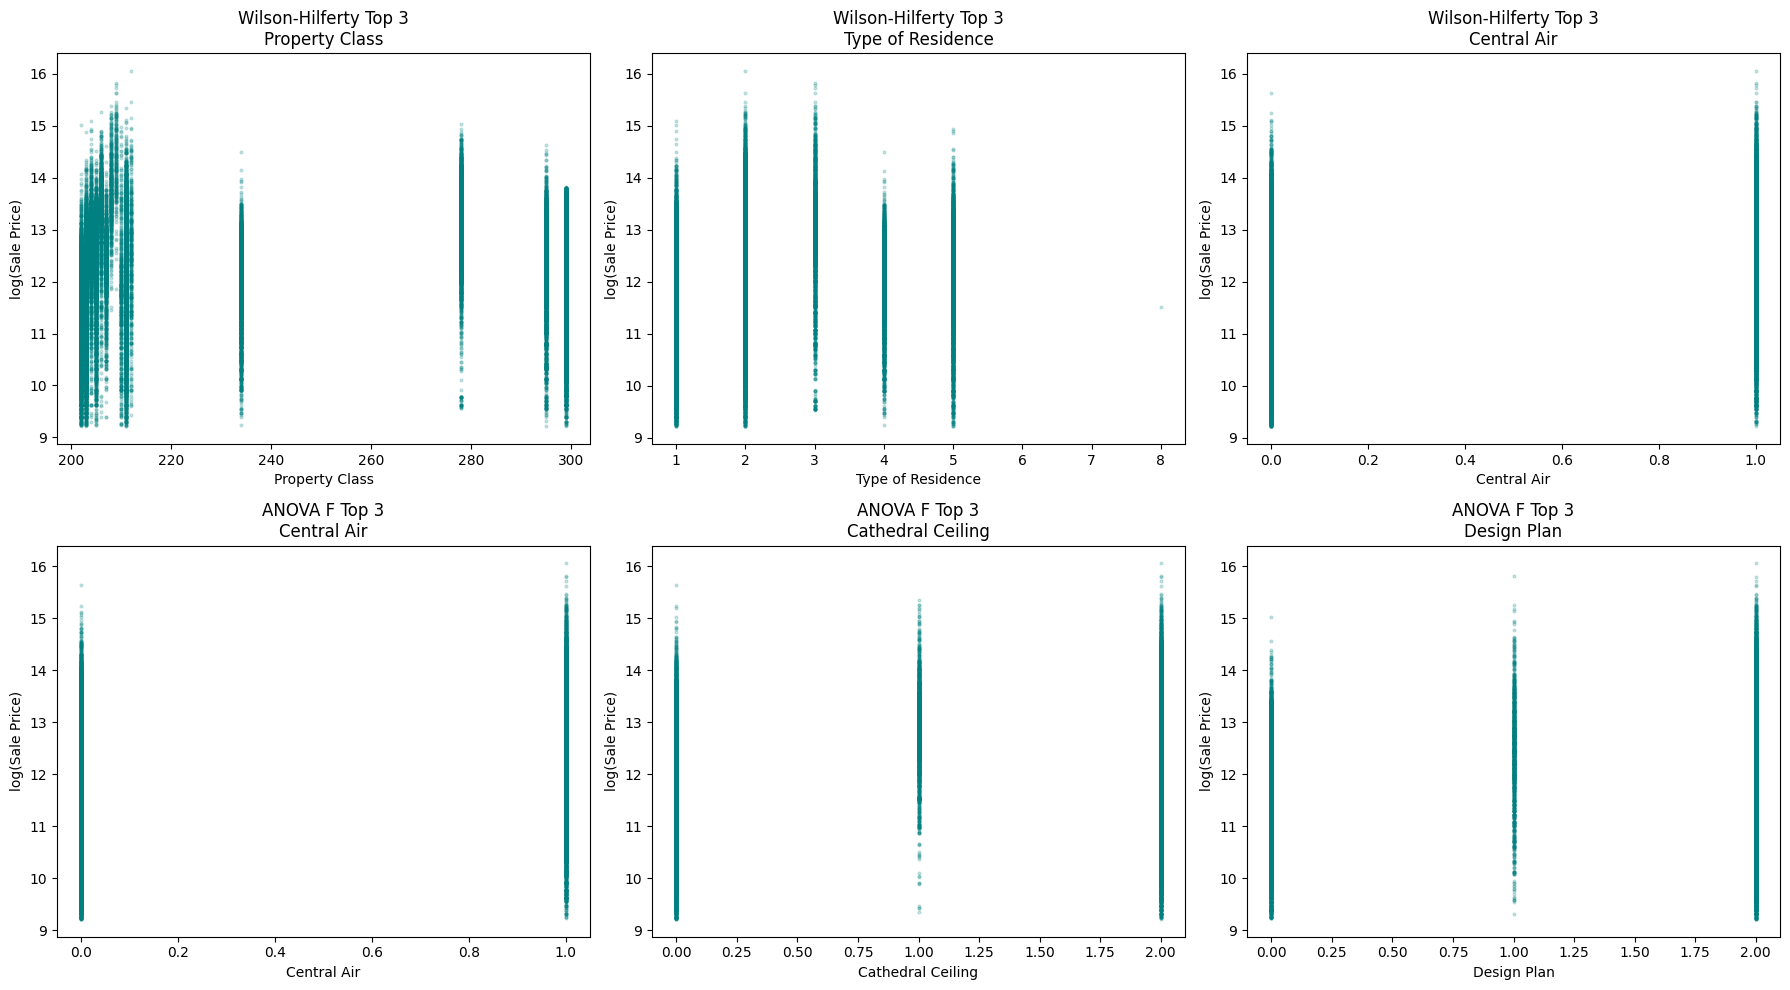

In [349]:

wh_top3    = [v for v in chi_df['Variable']    if v in df.columns and df[v].nunique() < 20][:3]
anova_top3 = [v for v in ranked_small.index    if v in df.columns and df[v].nunique() < 20][:3]

print("Wilson-Hilferty top 3:", wh_top3)
print("ANOVA F top 3:        ", anova_top3)

log_price = np.log(df['Sale Price'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (title, top3) in enumerate([
        ('Wilson-Hilferty Top 3', wh_top3),
        ('ANOVA F Top 3',         anova_top3)]):

    for col, var in enumerate(top3):
        ax = axes[row, col]

        x = df[var]
        if not pd.api.types.is_numeric_dtype(x):
            x = pd.Categorical(x).codes

        ax.scatter(x, log_price, s=4, alpha=0.2, color='teal')
        ax.set_xlabel(var)
        ax.set_ylabel('log(Sale Price)')
        ax.set_title(f'{title}\n{var}')

plt.tight_layout()
plt.show()


### 1.14 Boxplots — ANOVA top 5 categoricals

Visualise the top 5 from the low-cardinality ANOVA ranking. Each panel shows the within-category Sale Price distribution, ordered by group median. Variables that separate prices well show shifted, non-overlapping boxes.


/var/folders/1_/v_fdx3ys6l1d8vl2jlyg4k840000gn/T/ipykernel_87317/2729963007.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_groups, vert=False, labels=order,


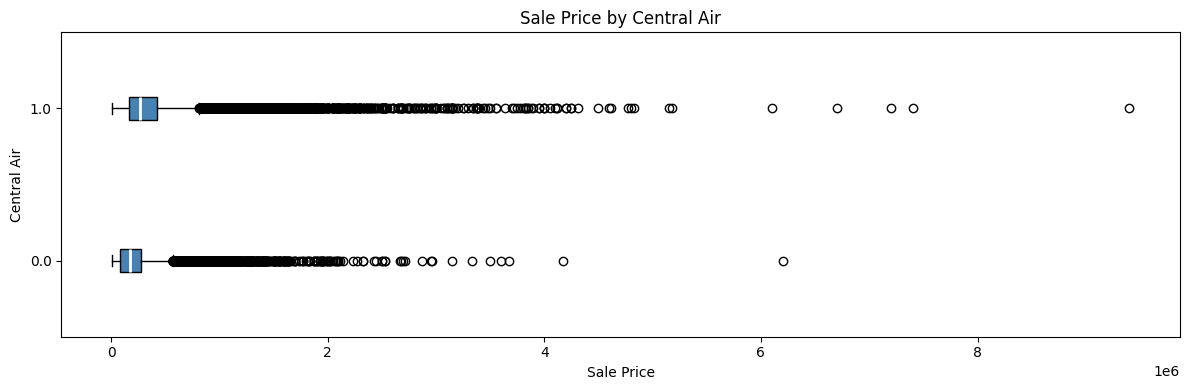

/var/folders/1_/v_fdx3ys6l1d8vl2jlyg4k840000gn/T/ipykernel_87317/2729963007.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_groups, vert=False, labels=order,


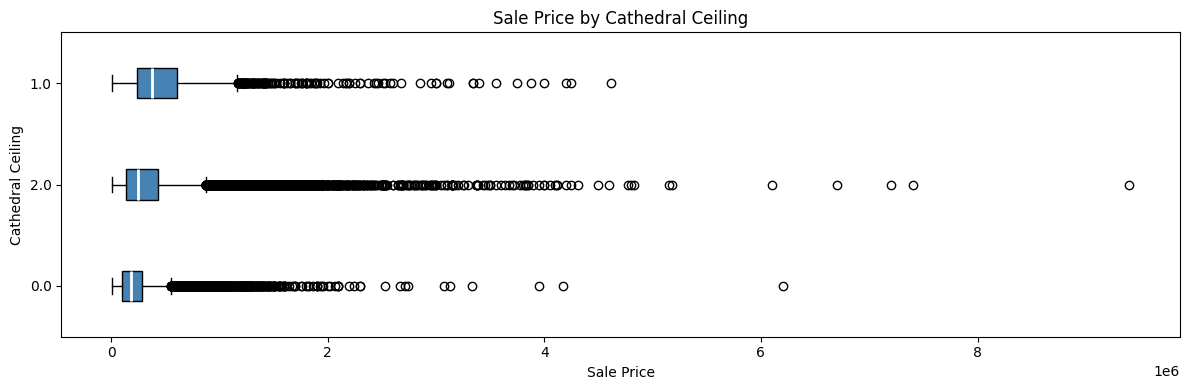

/var/folders/1_/v_fdx3ys6l1d8vl2jlyg4k840000gn/T/ipykernel_87317/2729963007.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_groups, vert=False, labels=order,


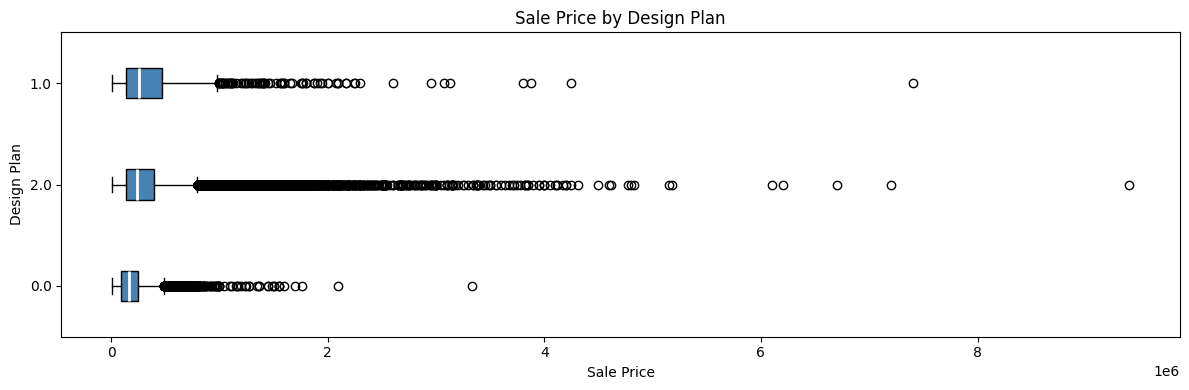

/var/folders/1_/v_fdx3ys6l1d8vl2jlyg4k840000gn/T/ipykernel_87317/2729963007.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_groups, vert=False, labels=order,


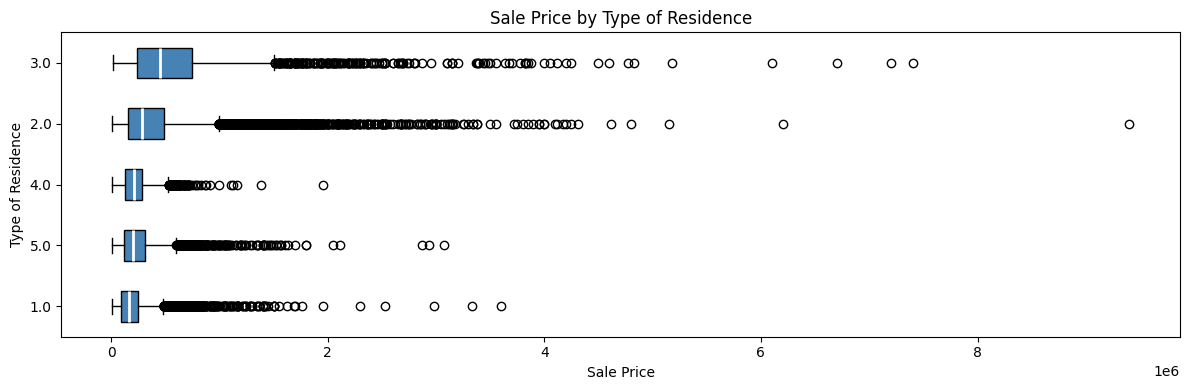

/var/folders/1_/v_fdx3ys6l1d8vl2jlyg4k840000gn/T/ipykernel_87317/2729963007.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_groups, vert=False, labels=order,


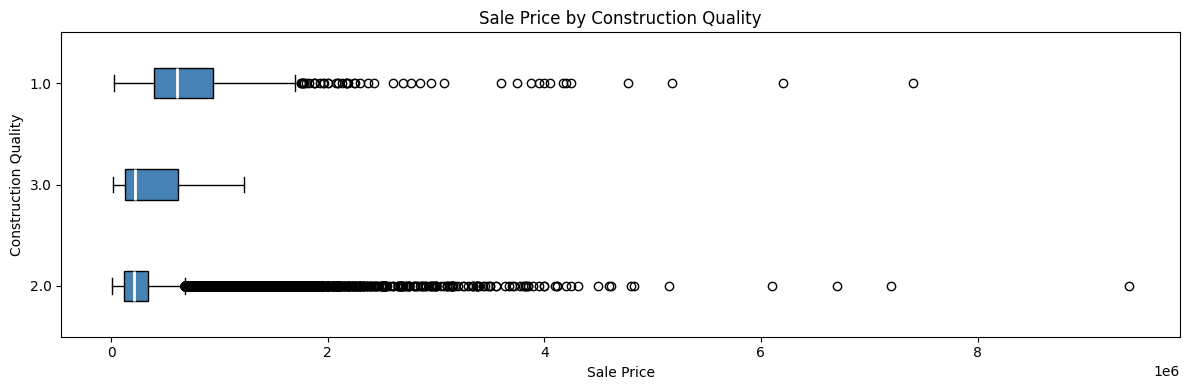

In [350]:

MIN_COUNT = 10

top_cats = ranked_small.head(5).index.tolist()

for col in top_cats:
    counts = df[col].value_counts()
    keep_cats = counts[counts >= MIN_COUNT].index
    sub = df[df[col].isin(keep_cats)]

    order = sub.groupby(col)['Sale Price'].median().sort_values().index
    fig, ax = plt.subplots(figsize=(12, max(4, len(order) * 0.4)))
    data_groups = [sub.loc[sub[col] == val, 'Sale Price'].dropna() for val in order]
    ax.boxplot(data_groups, vert=False, labels=order,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='black'),
               medianprops=dict(color='white', linewidth=2))
    ax.set_xlabel('Sale Price')
    ax.set_ylabel(col)
    ax.set_title(f'Sale Price by {col}')
    plt.tight_layout()
    plt.show()


### 1.15 Boxplots — Wilson-Hilferty (chi-squared) top 3 categoricals

Mirror of the ANOVA boxplots above, but using the top 3 predictors from the Wilson-Hilferty $\chi^2$ ranking (`chi_df`). Restricted to categoricals with fewer than 20 levels so the boxplots stay readable, and to columns still in `df` (so `Pure Market Filter` is skipped). Teal fill distinguishes them visually from the steel-blue ANOVA boxplots.

Side-by-side with the ANOVA cell, this answers: do the two ranking methods recommend the same variables for visual class separation?


Wilson-Hilferty top 3: ['Property Class', 'Type of Residence', 'Central Air']
ANOVA F top 3:         ['Central Air', 'Cathedral Ceiling', 'Design Plan']


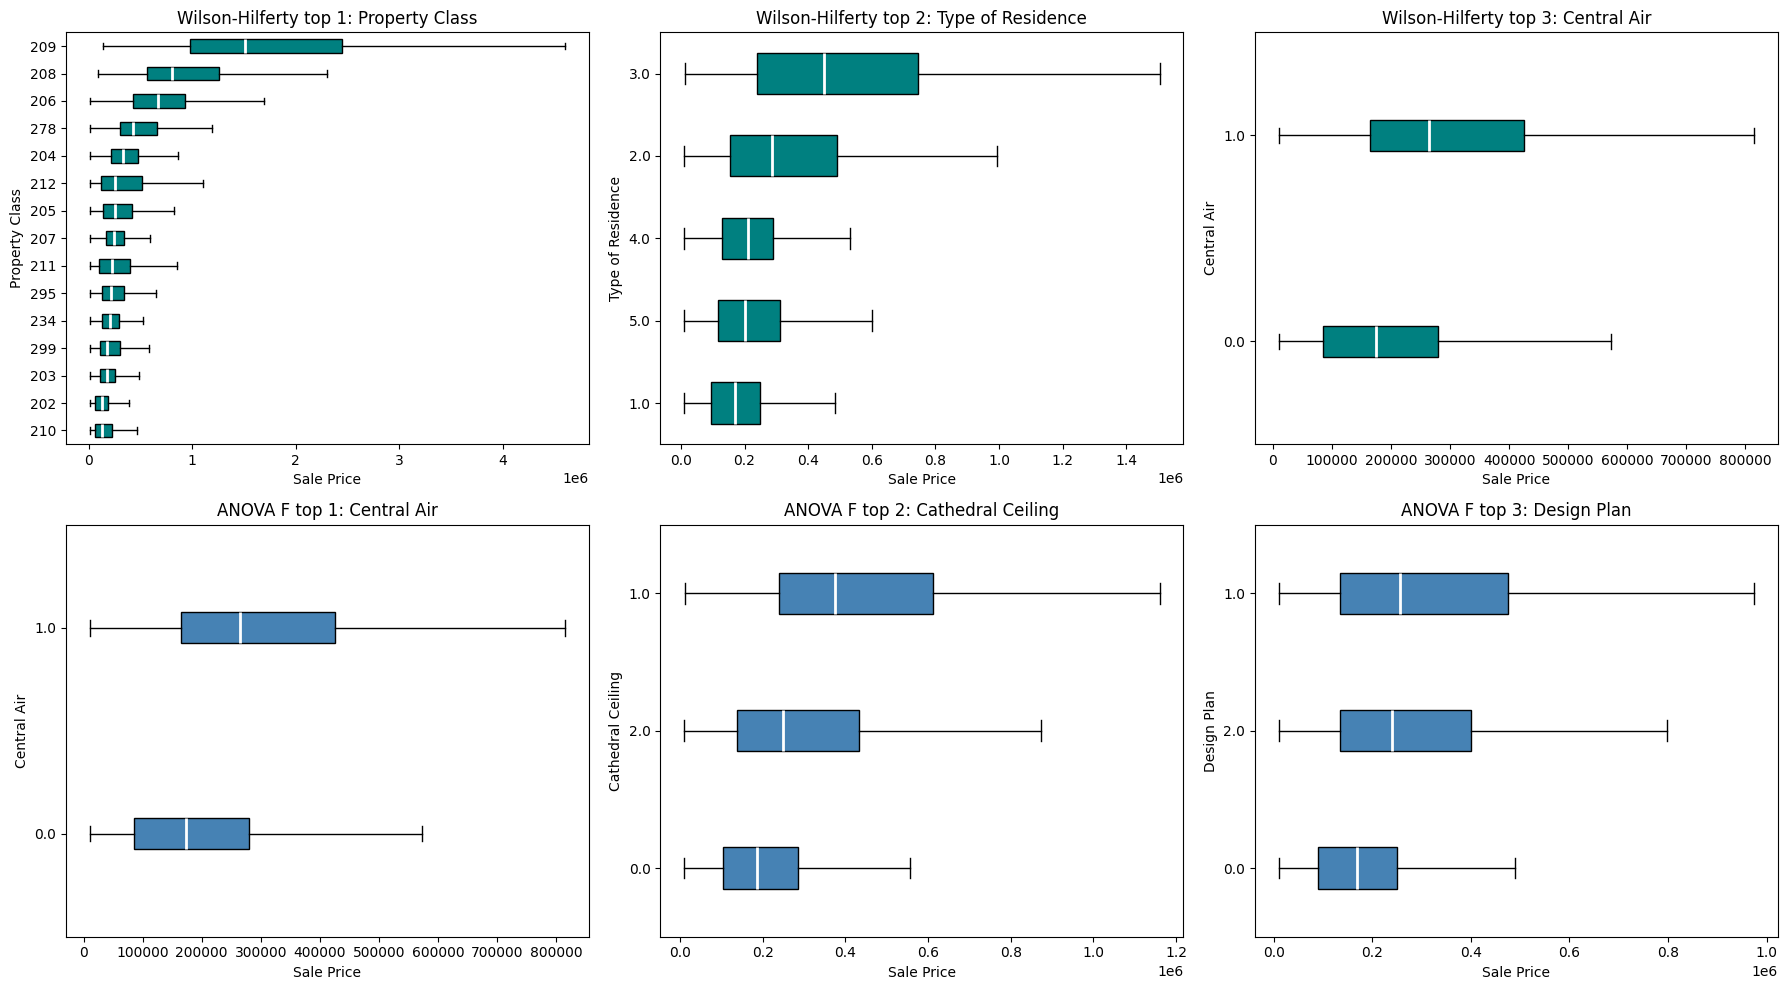

In [351]:

MIN_COUNT = 10

wh_top3 = [v for v in chi_df['Variable']
           if v in df.columns and df[v].nunique() < 20][:3]
anova_top3 = [v for v in ranked_small.index
              if v in df.columns and df[v].nunique() < 20][:3]

print(f'Wilson-Hilferty top 3: {wh_top3}')
print(f'ANOVA F top 3:         {anova_top3}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (label, top3, color) in enumerate([
        ('Wilson-Hilferty', wh_top3,    'teal'),
        ('ANOVA F',         anova_top3, 'steelblue')]):
    for col, var in enumerate(top3):
        ax = axes[row, col]
        counts = df[var].value_counts()
        keep_cats = counts[counts >= MIN_COUNT].index
        sub = df[df[var].isin(keep_cats)]

        order = sub.groupby(var)['Sale Price'].median().sort_values().index
        data_groups = [sub.loc[sub[var] == val, 'Sale Price'].dropna() for val in order]

        ax.boxplot(data_groups, vert=False, tick_labels=[str(v) for v in order],
                   patch_artist=True,
                   boxprops=dict(facecolor=color, color='black'),
                   medianprops=dict(color='white', linewidth=2),
                   showfliers=False)
        ax.set_xlabel('Sale Price')
        ax.set_ylabel(var)
        ax.set_title(f'{label} top {col+1}: {var}')

plt.tight_layout()
plt.show()


### 1.16 Ranking categories within each categorical column

Within **Modeling Group** and **Condition, Desirability and Utility**, rank individual categories by their median Sale Price. Median (not mean) because of the heavy right skew. Categories with fewer than `MIN_COUNT = 10` observations are dropped.


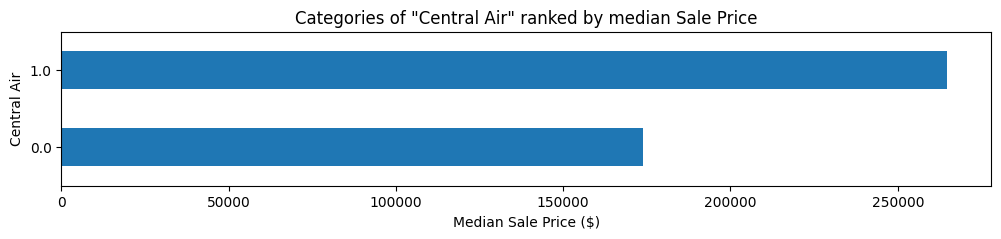

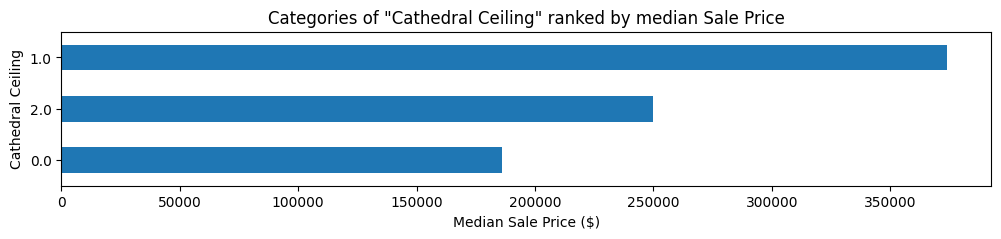

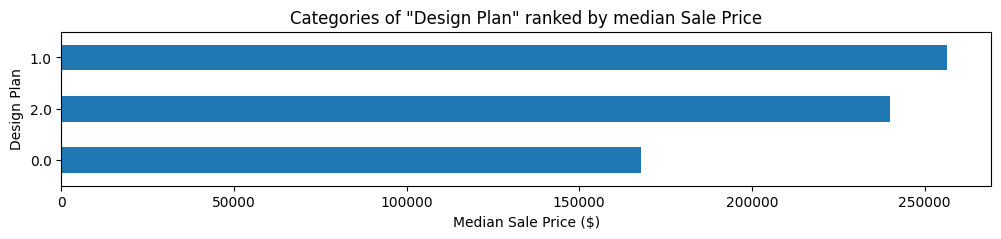

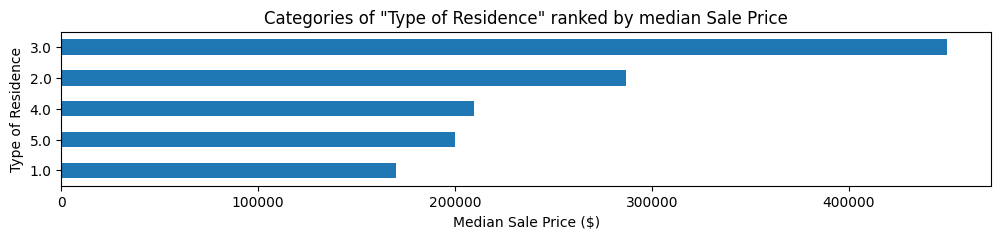

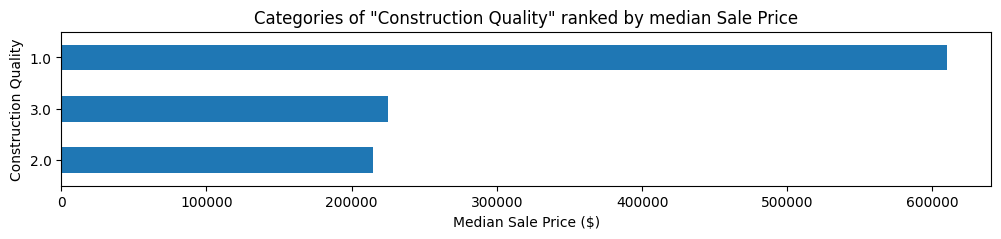

In [352]:
MIN_COUNT = 10
cat_cols_to_rank = ranked_small.head(5).index.tolist()

for col in cat_cols_to_rank:
    counts = df[col].value_counts()
    keep_cats = counts[counts >= MIN_COUNT].index
    sub = df[df[col].isin(keep_cats)]

    cat_medians = sub.groupby(col)['Sale Price'].median().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 2))
    cat_medians[::-1].plot.barh(ax=ax)
    ax.set_xlabel('Median Sale Price ($)')
    ax.set_title(f'Categories of "{col}" ranked by median Sale Price')

    plt.show()


### 1.17 Linear Discriminant Analysis (Sale Price tertiles)

LDA with target = log(Sale Price) binned into three tertiles. Numeric features only at first; cross-validation accuracy reported. We then add categoricals via one-hot encoding to test whether they improve class separation.


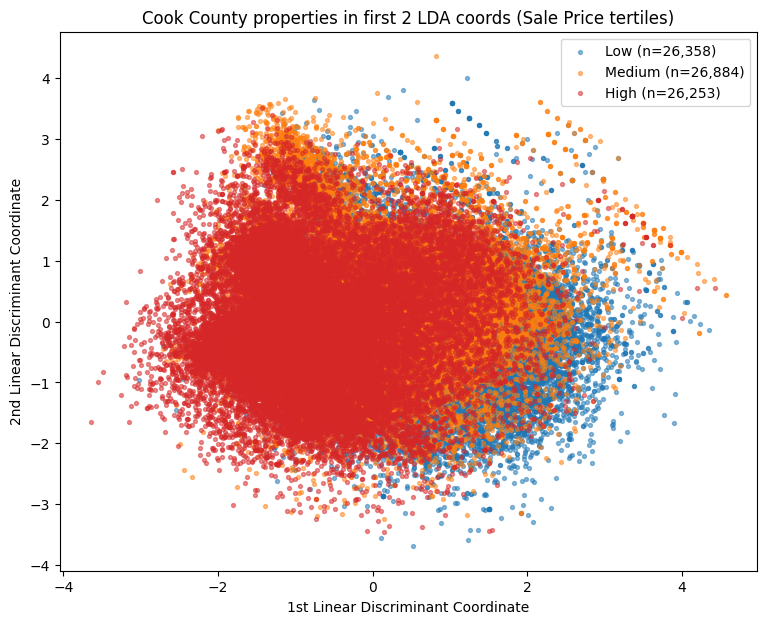

CV accuracy on training set: 0.543


In [353]:
price_tiers = pd.qcut(df['Sale Price'], q=3, labels=['Low', 'Medium', 'High'])

X = df.select_dtypes('number').drop(columns=['Sale Price'])
X = X[X.columns[X.isna().mean() < 0.10]]

data = pd.concat([X, price_tiers.rename('tier')], axis=1).dropna()

X = data.drop(columns='tier')
y = data['tier']

coords = LinearDiscriminantAnalysis(n_components=2).fit_transform(X, y)

fig, ax = plt.subplots(figsize=(9, 7))
colors = {'Low': 'tab:blue', 'Medium': 'tab:orange', 'High': 'tab:red'}

for tier, color in colors.items():
    sel = (y == tier).values
    ax.scatter(coords[sel, 0], coords[sel, 1], c=color,
               label=f'{tier} (n={sel.sum():,})', s=8, alpha=0.5)

ax.set_xlabel('1st Linear Discriminant Coordinate')
ax.set_ylabel('2nd Linear Discriminant Coordinate')
ax.set_title('Cook County properties in first 2 LDA coords (Sale Price tertiles)')
ax.legend()
plt.show()

lda = LinearDiscriminantAnalysis(n_components=2).fit(X, y)
print(f'CV accuracy on training set: {lda.score(X, y):.3f}')

In [354]:
lda = LinearDiscriminantAnalysis(n_components=2).fit(X, y)
print(f'CV accuracy on training set: {lda.score(X, y):.3f}')

CV accuracy on training set: 0.543


### 1.18 LDA with top categoricals one-hot encoded (NaN as its own level)


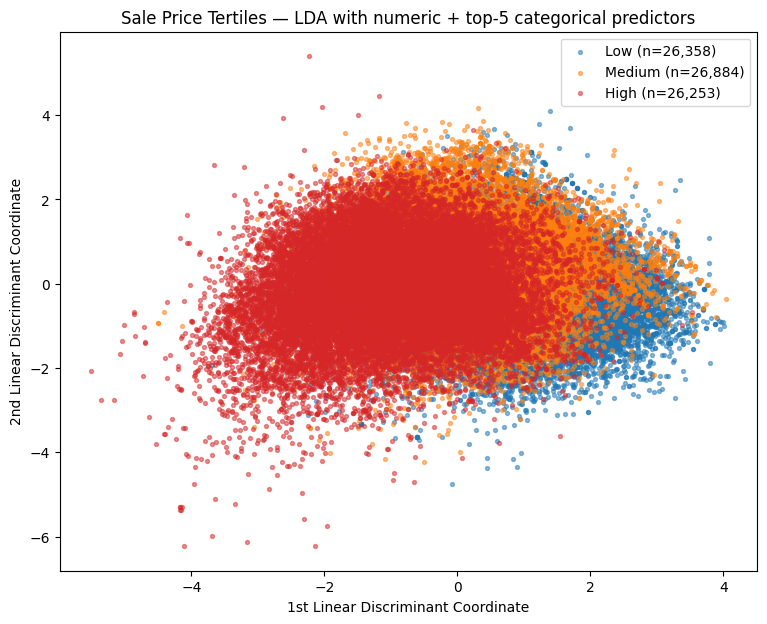

In [355]:
price_tiers = pd.qcut(df['Sale Price'], q=3, labels=['Low', 'Medium', 'High'])

num = df.select_dtypes('number').drop(columns=['Sale Price'])
num = num[num.columns[num.isna().mean() < 0.10]]

cats = pd.get_dummies(df[ranked_small.index.tolist()],
                      dummy_na=True).fillna(0).astype(int)

X = pd.concat([num, cats], axis=1)

data = pd.concat([X, price_tiers.rename('tier')], axis=1).dropna()
X = data.drop(columns='tier')
y = data['tier']

coords = LinearDiscriminantAnalysis(n_components=2).fit_transform(X, y)
fig, ax = plt.subplots(figsize=(9, 7))
colors = {'Low': 'tab:blue', 'Medium': 'tab:orange', 'High': 'tab:red'}

for tier, color in colors.items():
    sel = (y == tier).values
    ax.scatter(coords[sel, 0], coords[sel, 1], c=color,
               label=f'{tier} (n={sel.sum():,})', s=8, alpha=0.5)

ax.set_xlabel('1st Linear Discriminant Coordinate')
ax.set_ylabel('2nd Linear Discriminant Coordinate')
ax.set_title('Sale Price Tertiles — LDA with numeric + top-5 categorical predictors')
ax.legend()
plt.show()

In [356]:
lda = LinearDiscriminantAnalysis(n_components=2).fit(X, y)
print(f'CV accuracy on training set: {lda.score(X, y):.3f}')

CV accuracy on training set: 0.588


### 1.19 Significance test for the LDA accuracy jump

Is the increase in CV accuracy after adding categoricals (0.543 -> 0.588) significant? Two-proportion z-test on the difference.


In [357]:
n = len(y)
p_A, p_B = 0.543, 0.565
se = np.sqrt(p_A * (1 - p_A) / n + p_B * (1 - p_B) / n)
z = (p_B - p_A) / se
p_value = 2 * norm.sf(abs(z))

print(f'z-score: {z:.2f}')
print(f'p-value: {p_value:.2e}')

z-score: 8.83
p-value: 1.09e-18


### 1.20 Final cleaned dataset summary


In [358]:
df.describe()


,Property Class,Neighborhood Code,Land Square Feet,Town Code,Type of Residence,Apartments,Wall Material,Roof Material,Rooms,Bedrooms,...,Percent Ownership,Condo Class Factor,Multi-Family Indicator,Large Lot,O'Hare Noise,Floodplain,Road Proximity,Condo Strata,Sale Year,Most Recent Sale
count,80743.000000,80743.000000,8.074300e+04,80743.000000,56054.000000,56054.000000,56054.000000,56054.000000,56054.000000,56054.000000,...,24825.000000,24689.0,8498.000000,0.0,79543.000000,79543.000000,79543.000000,5308.000000,80743.000000,80693.000000
mean,244.463867,97.163667,6.225066e+04,47.736596,2.119260,0.388090,1.948264,1.170086,7.068755,3.535127,...,0.061489,299.0,211.055307,NaN,0.013288,0.042970,0.160869,5.138282,2016.069306,0.768654
std,43.939206,93.594610,2.486072e+05,24.139131,1.277436,1.042438,0.780907,0.613108,3.287580,1.508522,...,0.099264,0.0,0.228592,NaN,0.114508,0.202792,0.367412,2.506615,1.996170,0.421696
min,202.000000,10.000000,0.000000e+00,10.000000,1.000000,-5.000000,1.000000,1.000000,2.000000,1.000000,...,0.000000,299.0,211.000000,NaN,0.000000,0.000000,0.000000,1.000000,2013.000000,0.000000
25%,203.000000,31.000000,3.810000e+03,25.000000,1.000000,0.000000,1.000000,1.000000,5.000000,3.000000,...,0.000000,299.0,211.000000,NaN,0.000000,0.000000,0.000000,3.000000,2014.000000,1.000000
50%,211.000000,70.000000,6.750000e+03,38.000000,2.000000,0.000000,2.000000,1.000000,6.000000,3.000000,...,0.020000,299.0,211.000000,NaN,0.000000,0.000000,0.000000,5.000000,2016.000000,1.000000
75%,299.000000,120.000000,1.357450e+04,72.000000,2.000000,0.000000,2.000000,1.000000,8.000000,4.000000,...,0.070000,299.0,211.000000,NaN,0.000000,0.000000,0.000000,7.000000,2018.000000,1.000000
max,299.000000,600.000000,3.713027e+06,77.000000,8.000000,6.000000,4.000000,6.000000,48.000000,24.000000,...,0.900000,299.0,212.000000,NaN,1.000000,1.000000,1.000000,10.000000,2019.000000,1.000000


### 1.21 Log-transform skewed columns and export for GUIDE

Sale Price, Land Square Feet, and Building Square Feet have right skew > 2.5. Log-transform them and write the cleaned data + GUIDE descriptor file (`.dsc`) to disk.


In [359]:
import numpy as np

skewed = ['Sale Price', 'Land Square Feet', 'Building Square Feet']
df_out = df.copy()
for col in skewed:
    df_out[col] = np.log1p(df_out[col])
df_out = df_out.rename(columns={c: f'log {c}' for c in skewed})

out_path = 'cook_county_cleaned.csv'
df_out.to_csv(out_path, index=False)
print(f'wrote {out_path}: {df_out.shape[0]:,} rows x {df_out.shape[1]} cols')
df_out[[f'log {c}' for c in skewed]].describe()


wrote cook_county_cleaned.csv: 80,743 rows x 61 cols


,log Sale Price,log Land Square Feet,log Building Square Feet
count,80743.000000,80743.000000,56054.000000
mean,12.148342,9.200940,7.381377
std,0.894271,1.425924,0.461376
min,9.210940,0.000000,5.993961
25%,11.674202,8.245647,7.029973
50%,12.230770,8.817446,7.295056
75%,12.721889,9.516022,7.685703
max,16.056220,15.127358,9.884356


## 2. GUIDE Regression Tree


### 2.1 v1 baseline (stepwise-linear leaves, default config)

First GUIDE run on log Sale Price with stepwise-linear leaves and default options. Sets the baseline for everything that follows.


### 2.2 Configuration audit — are the chosen GUIDE options optimal?

Walk through the input-file choices that affect performance and check whether each one is the best fit for our data.


#### 2.2.1 Least squares vs least median squares

Least median squares is robust to outlier residuals; least squares is the right choice when residuals are roughly normal. We pick by inspecting the residual histogram.


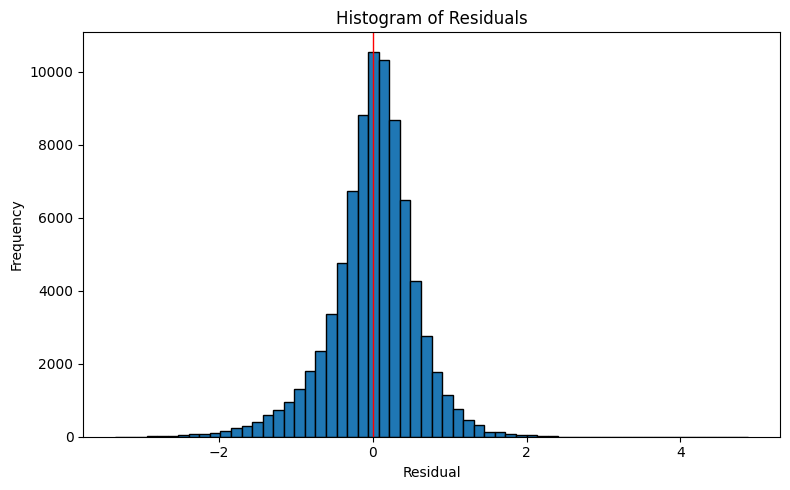

Mean residual:   -0.00
Median residual: 0.04
Std residual:    0.55
Skewness:        -0.567
Kurtosis:        2.197


In [360]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fitted = pd.read_csv(
    "cook_county_fitted.txt",
    sep=r"\s+",
    engine="python",
)

resid = fitted["observed"] - fitted["predicted"]

plt.figure(figsize=(8, 5))
plt.hist(resid, bins=60, edgecolor="black")
plt.axvline(0, color="red", lw=1)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Mean residual:   {resid.mean():,.2f}")
print(f"Median residual: {resid.median():,.2f}")
print(f"Std residual:    {resid.std():,.2f}")
print(f"Skewness:        {stats.skew(resid):.3f}")
print(f"Kurtosis:        {stats.kurtosis(resid):.3f}")

#### 2.2.2 Decision: use mean cross-validation (residuals are symmetric)

Residuals from the v1 fit are approximately normal (skew $\approx -0.57$, kurtosis $\approx 2.20$), so least-squares loss is appropriate and we use **Mean Cross Validation** rather than Median Cross Validation.


### 2.3 Roadmap for further MSE improvements

1. Treat the data as time-series and use the future years as a held-out test set (CV is misleading for time-series data).
2. Engineer time features from `Sale Date` (month, year, time-since-base).
3. Reduce redundancy among the multiple `Building Square Feet`-like variables.


_Each of the above is addressed in the sections below._


### 2.4 Step-wise vs multiple-linear leaves under 10-fold CV (pre-temporal-split data)

Before committing to a leaf-model choice, run both stepwise-linear and multiple-linear leaves under 10-fold cross-validation on the un-split training data and compare CV MSE.


**Side-by-side (10-fold CV on identical pre-split data):**

| Model | #Tnodes | CV MSE | CV RMSE | CV $R^2$ | Final (resub) $R^2$ |
|---|---:|---:|---:|---:|---:|
| Stepwise        | 34 | 0.2594 | 0.5093 | 0.676 | 0.6192 |
| Multiple-linear | 61 | 0.3410 | 0.5839 | 0.574 | 0.7002 |

Stepwise leaves win by a clean margin **and** with a substantially smaller tree (34 vs 61 leaves).


#### 2.4.1 Pruned CV tree — stepwise-linear leaves

![Stepwise CV tree (log Sale Price)](cook_county_tree_log.png)


#### 2.4.2 Pruned CV tree — multiple-linear leaves

![Multiple-linear CV tree (log Sale Price)](cook_county_cv_linear_tree.png)


In [361]:
df2 = pd.read_csv("cook_county_cleaned.csv")
df2["Sale Year"].unique()

array([2015., 2018., 2014., 2013., 2017., 2016., 2019.])

In [362]:
train_years = [2013, 2014, 2015, 2016, 2017]
test_years = [2018, 2019]

train_set = df2[df2["Sale Year"].isin(train_years)]
test_set  = df2[df2["Sale Year"].isin(test_years)]

### 2.5 Temporal train/test split (2013-2017 train, 2018-2019 test)

Write separate `cook_county_train.txt` and `cook_county_test.txt` for GUIDE to enforce a temporal hold-out, mirroring the production setting (predict next year's prices from past sales).


In [363]:
import csv
from pathlib import Path

def write_guide_txt(df, path):
    df.to_csv(path, sep=' ', index=False, quoting=csv.QUOTE_ALL,
              na_rep='NA', lineterminator='\n')
    print(f'wrote {path}: {df.shape[0]:,} rows x {df.shape[1]} cols')

def clone_dsc(src_dsc, new_txt_name, out_dsc):
    lines = Path(src_dsc).read_text().splitlines()
    lines[0] = new_txt_name
    Path(out_dsc).write_text('\n'.join(lines) + '\n')
    print(f'wrote {out_dsc}')

write_guide_txt(train_set, 'cook_county_train.txt')
write_guide_txt(test_set,  'cook_county_test.txt')

clone_dsc('cook_county_log.dsc', 'cook_county_train.txt', 'cook_county_train.dsc')
clone_dsc('cook_county_log.dsc', 'cook_county_test.txt',  'cook_county_test.dsc')

wrote cook_county_train.txt: 56,933 rows x 61 cols
wrote cook_county_test.txt: 23,810 rows x 61 cols
wrote cook_county_train.dsc
wrote cook_county_test.dsc


In [364]:

import subprocess, pandas as pd, numpy as np

r_cmd = '''
source("cook_county_train_test_predict.R")
write.table(
  data.frame(observed = as.numeric(newdata$log.Sale.Price), predicted = pred),
  file = "test_predictions.txt", row.names = FALSE, quote = FALSE
)
'''
result = subprocess.run(["Rscript", "-e", r_cmd], capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr)

preds = pd.read_csv("test_predictions.txt", sep=r"\s+")
resid = preds["observed"] - preds["predicted"]

rmse = np.sqrt((resid**2).mean())
mae  = resid.abs().mean()
r2   = 1 - (resid**2).sum() / ((preds["observed"] - preds["observed"].mean())**2).sum()

print(f"n test cases: {len(preds):,}")
print(f"Log RMSE:     {rmse:.4f}")
print(f"Log MAE:      {mae:.4f}")
print(f"Log R^2:      {r2:.4f}")


n test cases: 23,810
Log RMSE:     0.4864
Log MAE:      0.3461
Log R^2:      0.6410


In [365]:
import numpy as np

_obs   = np.expm1(preds["observed"])
_pred  = np.expm1(preds["predicted"])
_resid = _obs - _pred

_mse   = (_resid ** 2).mean()
_rmse  = np.sqrt(_mse)
_mae   = np.abs(_resid).mean()

print(f'Dollar MSE   : ${_mse:>16,.0f}')
print(f'Dollar RMSE  : ${_rmse:>16,.0f}')
print(f'Dollar MAE   : ${_mae:>16,.0f}')


Dollar MSE   : $  23,478,751,854
Dollar RMSE  : $         153,228
Dollar MAE   : $          84,980


### 2.6 Why temporal hold-out beats k-fold CV here

Property prices drift over time, so randomly-shuffled CV folds let the model peek at future-year sales -- inflating apparent accuracy. The 2013-2017 / 2018-2019 split prevents this leak.


### 2.7 Feature engineering for v2 and v3


#### 2.7.1 Add a numeric `Sale Month` column

Derive `Sale Month` from `Sale Date` (1-12) so the tree can split on intra-year seasonality.


In [366]:
train_set_w_month = train_set.copy()
test_set_w_month = test_set.copy()

train_set_w_month["Sale Month"] = pd.to_datetime(train_set_w_month["Sale Date"], format="%m/%d/%Y").dt.month
test_set_w_month["Sale Month"]  = pd.to_datetime(test_set_w_month["Sale Date"],  format="%m/%d/%Y").dt.month


In [367]:
train_df = train_set_w_month
test_df  = test_set_w_month


In [368]:
train_set_w_month

,Property Class,Neighborhood Code,log Land Square Feet,Town Code,Type of Residence,Apartments,Wall Material,Roof Material,Rooms,Bedrooms,...,Multi-Family Indicator,Large Lot,"Condition, Desirability and Utility",O'Hare Noise,Floodplain,Road Proximity,Condo Strata,Sale Year,Most Recent Sale,Sale Month
0,299,40,12.808745,76,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,1.0,NaN,2015.0,1.0,6
2,211,13,8.412055,77,3.0,6.0,2.0,2.0,24.0,12.0,...,211.0,NaN,NaN,0.0,0.0,0.0,NaN,2014.0,1.0,10
3,299,80,9.405002,20,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2013.0,1.0,3
5,204,100,10.431141,25,5.0,0.0,2.0,4.0,11.0,4.0,...,NaN,NaN,NaN,0.0,0.0,1.0,NaN,2014.0,1.0,9
6,299,72,9.995656,38,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2014.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80738,202,42,8.460834,21,1.0,0.0,2.0,1.0,4.0,3.0,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2016.0,1.0,11
80739,299,70,12.277844,29,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,1.0,NaN,2017.0,1.0,11
80740,299,60,11.303142,73,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2017.0,0.0,5
80741,299,93,10.223939,23,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,2013.0,1.0,1


In [369]:
train_set_w_month = train_set_w_month.copy()
test_set_w_month  = test_set_w_month.copy()

train_set_w_month["sqft"] = np.expm1(train_set_w_month["log Building Square Feet"])
if "Sale Price" in train_set_w_month.columns:
    train_set_w_month["price"] = train_set_w_month["Sale Price"]
elif "log Sale Price" in train_set_w_month.columns:
    train_set_w_month["price"] = np.expm1(train_set_w_month["log Sale Price"])
else:
    train_set_w_month["price"] = np.exp(train_set_w_month["log.Sale.Price"])
train_set_w_month["price_per_sqft"] = train_set_w_month["price"] / train_set_w_month["sqft"]

neighborhood_avg = train_set_w_month.groupby("Neighborhood Code")["price_per_sqft"].mean()
property_avg     = train_set_w_month.groupby("Property Class")["price_per_sqft"].mean()

train_set_w_month["HoodPriceSqFt"]   = train_set_w_month["Neighborhood Code"].map(neighborhood_avg)
train_set_w_month["PropClassPriceSqFt"] = train_set_w_month["Property Class"].map(property_avg)
test_set_w_month["HoodPriceSqFt"]    = test_set_w_month["Neighborhood Code"].map(neighborhood_avg)
test_set_w_month["PropClassPriceSqFt"]  = test_set_w_month["Property Class"].map(property_avg)

train_set_w_month = train_set_w_month.drop(columns=["sqft", "price", "price_per_sqft"], errors="ignore")

#### 2.7.2 v2: add `HoodPriceSqFt` and `PropClassPriceSqFt` features

For each row, look up the train-only mean price-per-square-foot in its Neighborhood Code and Property Class. Train statistics applied to test (no leakage).


In [370]:
import csv
from pathlib import Path

def write_guide_txt(df, path):
    df.to_csv(path, sep=' ', index=False, quoting=csv.QUOTE_ALL,
              na_rep='NA', lineterminator='\n')
    print(f'wrote {path}: {df.shape[0]:,} rows x {df.shape[1]} cols')

def clone_dsc(src_dsc, new_txt_name, out_dsc):
    lines = Path(src_dsc).read_text().splitlines()
    lines[0] = new_txt_name
    Path(out_dsc).write_text('\n'.join(lines) + '\n')
    print(f'wrote {out_dsc}')

new_cols = [
    ("Sale Month",              "n"),
    ("HoodPriceSqFt",   "n"),
    ("PropClassPriceSqFt", "n"),
]

base_lines = Path('cook_county_log.dsc').read_text().splitlines()
existing_n = len(base_lines) - 3

for i, (col_name, type_code) in enumerate(new_cols, start=existing_n + 1):
    base_lines.append(f'{i} "{col_name}" {type_code}')

Path('cook_county_log_v2.dsc').write_text('\n'.join(base_lines) + '\n')

write_guide_txt(train_set_w_month, 'cook_county_train_v2.txt')
write_guide_txt(test_set_w_month,  'cook_county_test_v2.txt')

clone_dsc('cook_county_log_v2.dsc', 'cook_county_train_v2.txt', 'cook_county_train_v2.dsc')


wrote cook_county_train_v2.txt: 56,933 rows x 64 cols
wrote cook_county_test_v2.txt: 23,810 rows x 64 cols
wrote cook_county_train_v2.dsc


In [371]:
import subprocess, pandas as pd, numpy as np

r_cmd = '''
source("cook_county_train_v2_predict.R")
write.table(
  data.frame(observed = as.numeric(newdata$log.Sale.Price), predicted = pred),
  file = "test_predictions_v2.txt", row.names = FALSE, quote = FALSE
)
'''
result = subprocess.run(["Rscript", "-e", r_cmd], capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr)

preds = pd.read_csv("test_predictions_v2.txt", sep=r"\s+")
resid = preds["observed"] - preds["predicted"]

mse  = (resid**2).mean()
rmse = np.sqrt(mse)
r2   = 1 - (resid**2).sum() / ((preds["observed"] - preds["observed"].mean())**2).sum()

print(f"Log MSE:        {mse:.4f}")
print(f"Log RMSE:       {rmse:.4f}")
print(f"Log R^2:        {r2:.4f}")
print(f"n:              {len(preds):,}")


Log MSE:        0.2462
Log RMSE:       0.4962
Log R^2:        0.6264
n:              23,810


In [372]:
import numpy as np

_obs   = np.expm1(preds["observed"])
_pred  = np.expm1(preds["predicted"])
_resid = _obs - _pred

_mse   = (_resid ** 2).mean()
_rmse  = np.sqrt(_mse)
_mae   = np.abs(_resid).mean()

print(f'Dollar MSE   : ${_mse:>16,.0f}')
print(f'Dollar RMSE  : ${_rmse:>16,.0f}')
print(f'Dollar MAE   : ${_mae:>16,.0f}')


Dollar MSE   : $  26,823,020,498
Dollar RMSE  : $         163,777
Dollar MAE   : $          90,602


In [373]:
train_set_w_month = train_set_w_month.copy()
train_set_w_month = train_set_w_month.drop(columns=['HoodPriceSqFt', 'PropClassPriceSqFt'], errors='ignore')
test_set_w_month  = test_set_w_month.copy()
test_set_w_month = test_set_w_month.drop(columns=['HoodPriceSqFt', 'PropClassPriceSqFt'], errors='ignore')

train_set_w_month["sqft"] = np.expm1(train_set_w_month["log Building Square Feet"])
neighborhood_avg = train_set_w_month.groupby("Neighborhood Code")["sqft"].mean()
property_avg     = train_set_w_month.groupby("Property Class")["sqft"].mean()

train_set_w_month["HoodSqFt"]   = train_set_w_month["Neighborhood Code"].map(neighborhood_avg)
train_set_w_month["PropClassSqFt"] = train_set_w_month["Property Class"].map(property_avg)
test_set_w_month["HoodSqFt"]    = test_set_w_month["Neighborhood Code"].map(neighborhood_avg)
test_set_w_month["PropClassSqFt"]  = test_set_w_month["Property Class"].map(property_avg)

train_set_w_month = train_set_w_month.drop(columns="sqft")

#### 2.7.3 Pruned tree v2 (`HoodPriceSqFt` + `PropClassPriceSqFt`)

![Pruned tree v2](cook_county_train_v2_tree.png)


In [374]:
import csv
from pathlib import Path

def write_guide_txt(df, path):
    df.to_csv(path, sep=' ', index=False, quoting=csv.QUOTE_ALL,
              na_rep='NA', lineterminator='\n')
    print(f'wrote {path}: {df.shape[0]:,} rows x {df.shape[1]} cols')

def clone_dsc(src_dsc, new_txt_name, out_dsc):
    lines = Path(src_dsc).read_text().splitlines()
    lines[0] = new_txt_name
    Path(out_dsc).write_text('\n'.join(lines) + '\n')
    print(f'wrote {out_dsc}')

new_cols = [
    ("Sale Month",              "n"),
    ("HoodSqFt",   "n"),
    ("PropClassSqFt", "n"),
]

base_lines = Path('cook_county_log.dsc').read_text().splitlines()
existing_n = len(base_lines) - 3

for i, (col_name, type_code) in enumerate(new_cols, start=existing_n + 1):
    base_lines.append(f'{i} "{col_name}" {type_code}')

Path('cook_county_log_v3.dsc').write_text('\n'.join(base_lines) + '\n')

write_guide_txt(train_set_w_month, 'cook_county_train_v3.txt')
write_guide_txt(test_set_w_month,  'cook_county_test_v3.txt')

clone_dsc('cook_county_log_v3.dsc', 'cook_county_train_v3.txt', 'cook_county_train_v3.dsc')


wrote cook_county_train_v3.txt: 56,933 rows x 64 cols
wrote cook_county_test_v3.txt: 23,810 rows x 64 cols
wrote cook_county_train_v3.dsc


In [375]:
import subprocess, pandas as pd, numpy as np

r_cmd = '''
source("cook_county_train_v3_predict.R")
write.table(
  data.frame(observed = as.numeric(newdata$log.Sale.Price), predicted = pred),
  file = "test_predictions_v3.txt", row.names = FALSE, quote = FALSE
)
'''
result = subprocess.run(["Rscript", "-e", r_cmd], capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr)

preds = pd.read_csv("test_predictions_v3.txt", sep=r"\s+")
resid = preds["observed"] - preds["predicted"]

mse  = (resid**2).mean()
rmse = np.sqrt(mse)
r2   = 1 - (resid**2).sum() / ((preds["observed"] - preds["observed"].mean())**2).sum()

print(f"Log MSE:        {mse:.4f}")
print(f"Log RMSE:       {rmse:.4f}")
print(f"Log R^2:        {r2:.4f}")
print(f"n:              {len(preds):,}")


Log MSE:        0.2315
Log RMSE:       0.4811
Log R^2:        0.6487
n:              23,810


In [376]:
import numpy as np

_obs   = np.expm1(preds["observed"])
_pred  = np.expm1(preds["predicted"])
_resid = _obs - _pred

_mse   = (_resid ** 2).mean()
_rmse  = np.sqrt(_mse)
_mae   = np.abs(_resid).mean()

print(f'Dollar MSE   : ${_mse:>16,.0f}')
print(f'Dollar RMSE  : ${_rmse:>16,.0f}')
print(f'Dollar MAE   : ${_mae:>16,.0f}')


Dollar MSE   : $  23,535,421,293
Dollar RMSE  : $         153,413
Dollar MAE   : $          84,798


![GUIDE Regression Tree](cook_county_train_v3_tree.png)

#### 2.8.1 Why price-per-sqft features hurt R$^2$

The earlier `HoodPriceSqFt` and `PropClassPriceSqFt` columns were computed from train Sale Prices, so they leak the target into the features. Cross-validation accuracy looked plausible because each fold used train-only statistics, but the test-set R$^2$ dropped because the test rows hadn't contributed to the lookup means and the target leak inflated the apparent within-train fit.


In [377]:
import subprocess, pandas as pd, numpy as np

r_cmd = '''
source("cook_county_train_linear_predict.R")
write.table(
  data.frame(observed = as.numeric(newdata$log.Sale.Price), predicted = pred),
  file = "test_predictions_linear.txt", row.names = FALSE, quote = FALSE
)
'''
result = subprocess.run(["Rscript", "-e", r_cmd], capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr)

preds = pd.read_csv("test_predictions_linear.txt", sep=r"\s+")
resid = preds["observed"] - preds["predicted"]

mse  = (resid**2).mean()
rmse = np.sqrt(mse)
r2   = 1 - (resid**2).sum() / ((preds["observed"] - preds["observed"].mean())**2).sum()

print(f"Log MSE:        {mse:.4f}")
print(f"Log RMSE:       {rmse:.4f}")
print(f"Log R^2:        {r2:.4f}")
print(f"n:              {len(preds):,}")


Log MSE:        0.2328
Log RMSE:       0.4825
Log R^2:        0.6468
n:              23,810


In [378]:
import numpy as np

_obs   = np.expm1(preds["observed"])
_pred  = np.expm1(preds["predicted"])
_resid = _obs - _pred

_mse   = (_resid ** 2).mean()
_rmse  = np.sqrt(_mse)
_mae   = np.abs(_resid).mean()

print(f'Dollar MSE   : ${_mse:>16,.0f}')
print(f'Dollar RMSE  : ${_rmse:>16,.0f}')
print(f'Dollar MAE   : ${_mae:>16,.0f}')


Dollar MSE   : $  43,207,891,737
Dollar RMSE  : $         207,865
Dollar MAE   : $          90,862


#### 2.8.2 v3 pruned tree, multiple-linear leaves (test set)

![v3 multiple-linear temporal tree](cook_county_train_linear_tree.png)

Multiple-linear leaves on v3: Log MSE = 0.2328, Log RMSE = 0.4825, Log $R^2$ = 0.6468 -- slightly worse than the stepwise-linear v3 (0.2315 / 0.4811 / 0.6487).


---
**Random Forest (temporal training window 2013-2017, $n = 56{,}933$)**

Stats read directly from `cook_county_forest.out` (no R prediction script was generated for this run, so we use the `.out` file just like the CV-based tree runs):

- Line 126: `Resubstitution estimate of root mean squared error (RMSE): .4187`
- Line 128: `Proportion of variance (R-squared) explained by ensemble model: 0.7937` (training)
- Line 131: `OOB estimate of root mean squared error: .4438`

From these we recover
$\mathrm{Var}(\log\text{Sale Price})_{\text{train}} = 0.4187^2/(1 - 0.7937) \approx 0.8498$,
and convert the OOB RMSE into the same RMSE / MSE / $R^2$ trio used for the trees:

| Estimate | Log MSE | Log RMSE | Log $R^2$ |
|---|---:|---:|---:|
| Resubstitution (training) | 0.1753 | 0.4187 | 0.7937 |
| OOB (honest)              | 0.1970 | 0.4438 | 0.7682 |

The OOB row is the appropriate predictive comparison against the GUIDE-tree CV/temporal numbers; the resubstitution row is shown only to illustrate the optimism of in-sample fit.


In [379]:
import pandas as pd, numpy as np

forest_pred = pd.read_csv("cook_county_forest_fitted.txt", sep=r'\s+')
y      = forest_pred["observed"].astype(float)
y_hat  = forest_pred["predicted"].astype(float)
resid  = y - y_hat

mse  = (resid ** 2).mean()
rmse = np.sqrt(mse)
r2   = 1 - mse / y.var(ddof=0)

print(f"Random Forest (training window 2013-2017, n = {len(y)})")
print(f"Log MSE : {mse:.4f}")
print(f"Log RMSE: {rmse:.4f}")
print(f"Log R^2 : {r2:.4f}")

Random Forest (training window 2013-2017, n = 56933)
Log MSE : 0.1752
Log RMSE: 0.4186
Log R^2 : 0.7938


In [380]:
import numpy as np

_obs   = np.expm1(y)
_pred  = np.expm1(y_hat)
_resid = _obs - _pred

_mse   = (_resid ** 2).mean()
_rmse  = np.sqrt(_mse)
_mae   = np.abs(_resid).mean()
_mdape = np.median(np.abs(_resid) / _obs) * 100

print(f'Dollar MSE   : ${_mse:>16,.0f}')
print(f'Dollar RMSE  : ${_rmse:>16,.0f}')
print(f'Dollar MAE   : ${_mae:>16,.0f}')

Dollar MSE   : $  19,272,777,247
Dollar RMSE  : $         138,826
Dollar MAE   : $          65,977


## 3. Linear and Ridge Regression


### 3.1 Linear regression with sklearn pipeline (impute + one-hot + scale)

Baseline parametric model on the v3 features. Pipeline: median imputation -> standard scaling for numerics + median imputation -> one-hot encoding for low-cardinality categoricals from the WH ranking.


In [381]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import numpy as np

target = 'log Sale Price'

cat_cols = (chi_df[chi_df['Variable']
                   .apply(lambda c: c in train_df.columns and train_df[c].nunique() <= 10)]
            .head(10)['Variable'].tolist())

num_cols = [c for c in train_df.select_dtypes('number').columns
            if c != target and c not in cat_cols]

num = Pipeline([('imp', SimpleImputer(strategy='median')),
                ('sc',  StandardScaler())])
cat = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                ('oh',  OneHotEncoder(handle_unknown='ignore'))])

prep = ColumnTransformer([('num', num, num_cols),
                          ('cat', cat, cat_cols)])

model = Pipeline([('prep', prep), ('lr', LinearRegression())])
model.fit(train_df[num_cols + cat_cols], train_df[target])
preds = model.predict(test_df[num_cols + cat_cols])

y = test_df[target].to_numpy()
mse = ((preds - y) ** 2).mean()
print(f'Log MSE:  {mse:.4f}')
print(f'Log RMSE: {np.sqrt(mse):.4f}')
print(f'Log R^2:  {1 - mse/y.var():.4f}')

/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Large Lot']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Condo Strata']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Log MSE:  0.3537
Log RMSE: 0.5947
Log R^2:  0.4633


/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Large Lot']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Condo Strata']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [382]:
_obs   = np.expm1(y)
_pred  = np.expm1(preds)
_resid = _obs - _pred

_mse   = (_resid ** 2).mean()
_rmse  = np.sqrt(_mse)
_mae   = np.abs(_resid).mean()

print(f'Dollar MSE   : ${_mse:>16,.0f}')
print(f'Dollar RMSE  : ${_rmse:>16,.0f}')
print(f'Dollar MAE   : ${_mae:>16,.0f}')


Dollar MSE   : $  39,419,770,469
Dollar RMSE  : $         198,544
Dollar MAE   : $         114,527


In [383]:
from sklearn.linear_model import Ridge

target = 'log Sale Price'

cat_cols = (chi_df[chi_df['Variable']
                   .apply(lambda c: c in train_df.columns and train_df[c].nunique() <= 10)]
            .head(10)['Variable'].tolist())

num_cols = [c for c in train_df.select_dtypes('number').columns
            if c != target and c not in cat_cols]

num = Pipeline([('imp', SimpleImputer(strategy='median')),
                ('sc',  StandardScaler())])
cat = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                ('oh',  OneHotEncoder(handle_unknown='ignore'))])

prep = ColumnTransformer([('num', num, num_cols),
                          ('cat', cat, cat_cols)])

model = Pipeline([('prep', prep), ('lr', Ridge(alpha=0.1))])
model.fit(train_df[num_cols + cat_cols], train_df[target])
preds = model.predict(test_df[num_cols + cat_cols])

y = test_df[target].to_numpy()
mse = ((preds - y) ** 2).mean()
print(f'Log MSE:  {mse:.4f}')
print(f'Log RMSE: {np.sqrt(mse):.4f}')
print(f'Log R^2:  {1 - mse/y.var():.4f}')

/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Large Lot']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Condo Strata']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Log MSE:  0.3534
Log RMSE: 0.5945
Log R^2:  0.4637


/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Large Lot']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Condo Strata']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [384]:
_obs   = np.expm1(y)
_pred  = np.expm1(preds)
_resid = _obs - _pred

_mse   = (_resid ** 2).mean()
_rmse  = np.sqrt(_mse)
_mae   = np.abs(_resid).mean()

print(f'Dollar MSE   : ${_mse:>16,.0f}')
print(f'Dollar RMSE  : ${_rmse:>16,.0f}')
print(f'Dollar MAE   : ${_mae:>16,.0f}')


Dollar MSE   : $  39,433,585,246
Dollar RMSE  : $         198,579
Dollar MAE   : $         114,470


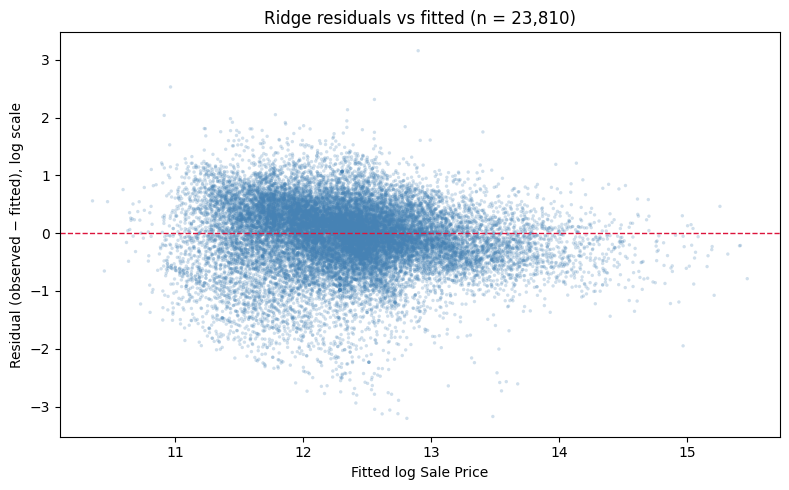

Residual mean:   -0.0556
Residual median: -0.0104
Residual std:    0.5919


In [385]:

resid_log = y - preds

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(preds, resid_log, s=6, alpha=0.25, color='steelblue', edgecolor='none')
ax.axhline(0, color='crimson', linestyle='--', linewidth=1)
ax.set_xlabel('Fitted log Sale Price')
ax.set_ylabel('Residual (observed − fitted), log scale')
ax.set_title(f'Ridge residuals vs fitted (n = {len(y):,})')
plt.tight_layout()
plt.show()

print(f'Residual mean:   {resid_log.mean():.4f}')
print(f'Residual median: {np.median(resid_log):.4f}')
print(f'Residual std:    {resid_log.std():.4f}')


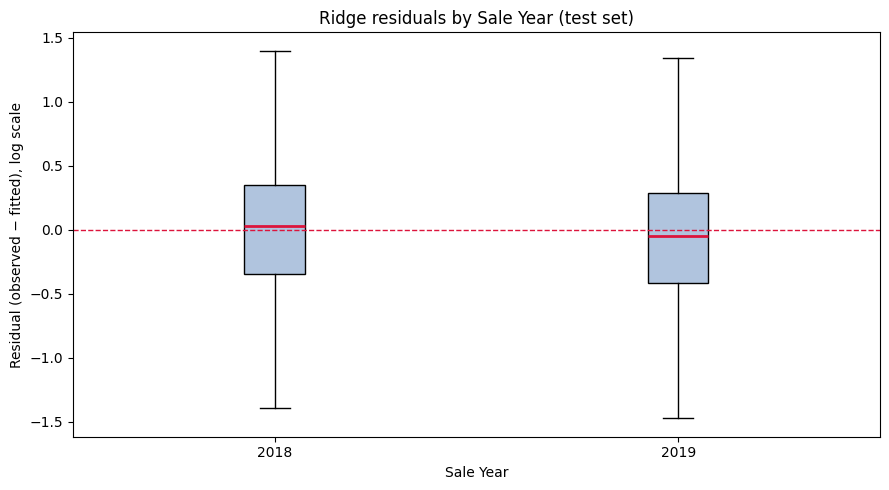

In [386]:
years = test_df['Sale Year'].to_numpy()
year_levels = np.sort(np.unique(years))
groups = [resid_log[years == yr] for yr in year_levels]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(groups, tick_labels=[int(yr) for yr in year_levels], showfliers=False,
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'),
           medianprops=dict(color='crimson', linewidth=2))
ax.axhline(0, color='crimson', linestyle='--', linewidth=1)
ax.set_xlabel('Sale Year')
ax.set_ylabel('Residual (observed − fitted), log scale')

ax.set_title('Ridge residuals by Sale Year (test set)')
plt.tight_layout()
plt.show()


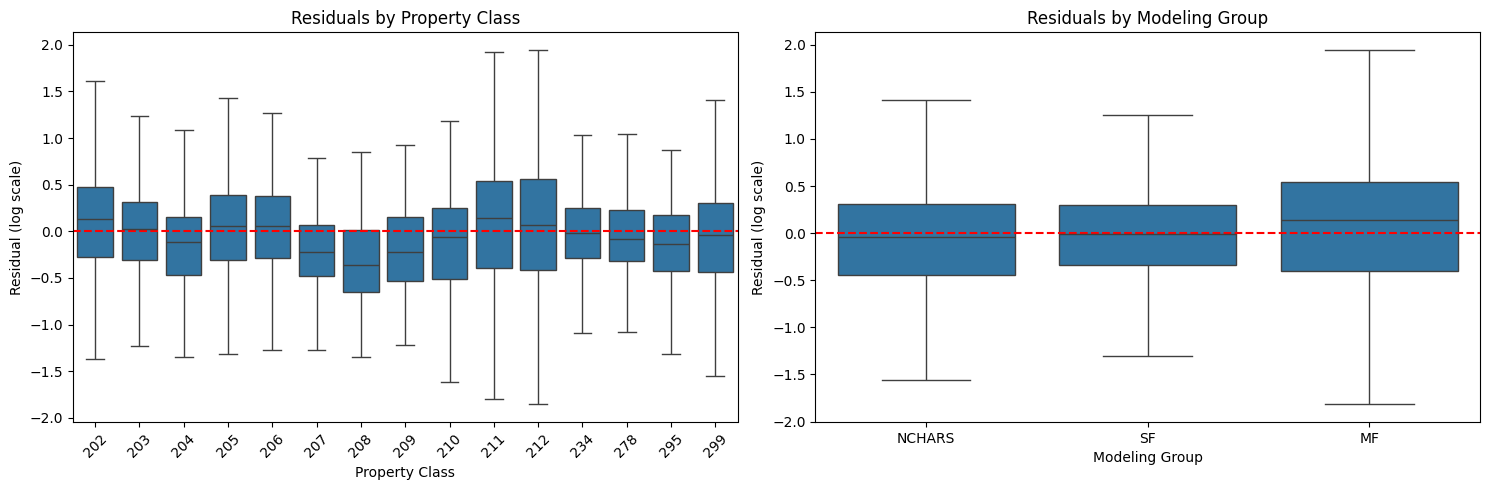

In [387]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, title in [(axes[0], 'Property Class', 'Residuals by Property Class'),
                       (axes[1], 'Modeling Group', 'Residuals by Modeling Group')]:

    sns.boxplot(x=col, y=resid_log, data=test_df, ax=ax, showfliers=False)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Residual (log scale)')

    if col == 'Property Class':
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

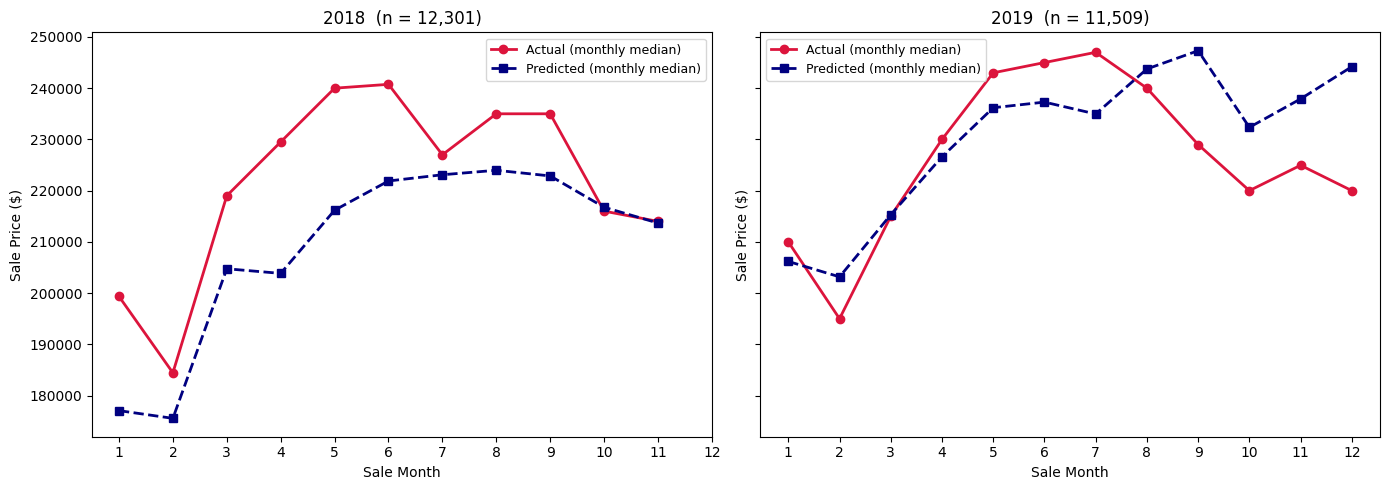

In [388]:
obs_dollar  = np.expm1(y)
pred_dollar = np.expm1(preds)
years  = test_df['Sale Year'].to_numpy()

if 'Sale Month' in test_df.columns:
    months = test_df['Sale Month'].to_numpy()
else:
    months = pd.to_datetime(test_df['Sale Date'], format='%m/%d/%Y').dt.month.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, yr in zip(axes, [2018, 2019]):
    mask = (years == yr)
    actual_by_m = pd.Series(obs_dollar[mask]).groupby(months[mask]).median().sort_index()
    pred_by_m   = pd.Series(pred_dollar[mask]).groupby(months[mask]).median().sort_index()

    ax.plot(actual_by_m.index, actual_by_m.values, marker='o', color='crimson',
            linewidth=2, label='Actual (monthly median)')
    ax.plot(pred_by_m.index,   pred_by_m.values,   marker='s', color='navy',
            linewidth=2, linestyle='--', label='Predicted (monthly median)')
    ax.set_xlabel('Sale Month')
    ax.set_ylabel('Sale Price ($)')
    ax.set_title(f'{yr}  (n = {mask.sum():,})')
    ax.set_xticks(range(1, 13))
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()


In [389]:
imp = pd.read_csv('cook_county_v3_importance_scores.txt',
                  sep=r'\s+')

imp

,Rank,Group,Score,Missing,Variable
0,1,A,866.700,0,Town.Code
1,2,A,604.400,0,Neighborhood.Code
2,3,A,564.000,0,Property.Class
3,4,A,472.900,17269,log.Building.Square.Feet
4,5,A,430.600,991,Latitude
5,6,A,347.500,17269,Rooms
6,7,A,346.400,17269,Fireplaces
7,8,A,313.500,17269,Full.Baths
8,9,A,299.400,17269,PropClassSqFt
9,10,A,294.200,17269,Type.of.Residence


### 3.2 Ridge with GUIDE-importance-ranked variables only

Restrict features to those GUIDE flagged as important in `cook_county_v3_importance_scores.txt`. Ridge with $\alpha = 0.1$.


In [390]:
target = 'log Sale Price'

imp = pd.read_csv('cook_county_v3_importance_scores.txt', sep=r'\s+')
guide_vars = (imp['Variable']
              .str.replace('.', ' ', regex=False)
              .tolist())

guide_vars = [v for v in guide_vars
              if v in train_df.columns and v != target]

num_cols = [c for c in guide_vars if pd.api.types.is_numeric_dtype(train_df[c])]
cat_cols = [c for c in guide_vars if c not in num_cols]

num = Pipeline([('imp', SimpleImputer(strategy='median')),
                ('sc',  StandardScaler())])
cat = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                ('oh',  OneHotEncoder(handle_unknown='ignore'))])

prep = ColumnTransformer([('num', num, num_cols),
                          ('cat', cat, cat_cols)])

model = Pipeline([('prep', prep), ('lr', Ridge(alpha=0.1))])
model.fit(train_df[num_cols + cat_cols], train_df[target])
preds = model.predict(test_df[num_cols + cat_cols])

y = test_df[target].to_numpy()
mse = ((preds - y) ** 2).mean()
print(f'Log MSE:  {mse:.4f}')
print(f'Log RMSE: {np.sqrt(mse):.4f}')
print(f'Log R^2:  {1 - mse/y.var():.4f}')

Log MSE:  0.3541
Log RMSE: 0.5950
Log R^2:  0.4627


### 3.3 Identifying redundancy via correlation + matched missingness

Within the high-correlation pairs ($|r| > 0.8$), flag pairs whose two members have nearly identical missingness percentages -- a second redundancy signal layered on top of correlation.


In [391]:
num = train_df.select_dtypes('number')
corr_matrix = num.corr().abs()
miss_rate = num.isna().mean()
high_corr_pairs = []

for i in range(len(num.columns)):
    for j in range(i + 1, len(num.columns)):
        var1 = num.columns[i]
        var2 = num.columns[j]

        correlation = corr_matrix.iloc[i, j]

        if correlation > 0.7:
            miss1 = miss_rate[var1] * 100
            miss2 = miss_rate[var2] * 100

            high_corr_pairs.append({
                'Variable A'      : var1,
                'Variable B'      : var2,
                'Correlation'     : round(correlation, 4),
                'Missing A (%)'   : round(miss1, 2),
                'Missing B (%)'   : round(miss2, 2),
                'Diff in Missing (%)': round(abs(miss1 - miss2), 2)
            })

result = pd.DataFrame(high_corr_pairs)
result = result.sort_values(by='Diff in Missing (%)', ascending=False)

result

,Variable A,Variable B,Correlation,Missing A (%),Missing B (%),Diff in Missing (%)
0,Property Class,Multi-Family Indicator,1.0000,0.00,89.45,89.45
11,Renovation,Garage 2 Area,1.0000,99.87,30.33,69.54
17,Multi Code,Total Building Square Feet,0.7992,30.33,98.49,68.16
18,Number of Commercial Units,Multi-Family Indicator,0.9010,30.33,89.45,59.12
4,Apartments,Use,0.8762,30.33,0.00,30.33
10,Attic Type,Attic Finish,0.7964,30.33,0.00,30.33
1,Town Code,Census Tract,0.7444,0.00,1.74,1.74
5,Rooms,Bedrooms,0.9062,30.33,30.33,0.00
6,Rooms,log Building Square Feet,0.7494,30.33,30.33,0.00
7,Rooms,Full Baths,0.7641,30.33,30.33,0.00


### 3.4 Drop redundant variables (lowest GUIDE importance loses)

For each redundant pair, drop the partner with the lower GUIDE importance score (`var_to_drop` list).


In [392]:
high_corr_zero_gap = result[result["Diff in Missing (%)"] == 0].copy()

imp["var_clean"] = imp['Variable'].str.replace('.', ' ', regex=False)
imp_score_dict = dict(zip(imp["var_clean"], imp["Score"]))

var_to_drop = []

for _, row in high_corr_zero_gap.iterrows():
    first_var = row["Variable A"]
    second_var = row["Variable B"]

    score_a = imp_score_dict.get(first_var, 0)
    score_b = imp_score_dict.get(second_var, 0)

    if score_a <= score_b:
        var_to_drop.append(first_var)
    else:
        var_to_drop.append(second_var)

var_to_drop

['Bedrooms',
 'Rooms',
 'Full Baths',
 'Bedrooms',
 'Apartments',
 'Garage 1 Area',
 'Garage 2 Size',
 'Garage 2 Size',
 'Garage 2 Attachment',
 'Full Baths',
 'Apartments',
 'Bedrooms']

In [393]:
from sklearn.linear_model import Ridge

target = 'log Sale Price'

cat_cols = (chi_df[chi_df['Variable']
                   .apply(lambda c: c in train_df.columns and train_df[c].nunique() <= 10)]
            .head(10)['Variable'].tolist())

num_cols = [c for c in train_df.select_dtypes('number').columns
            if c != target and c not in cat_cols]

num_cols = [c for c in num_cols if c not in var_to_drop]
cat_cols = [c for c in cat_cols if c not in var_to_drop]

print(f"Final features used → {len(num_cols)} numeric + {len(cat_cols)} categorical")

num = Pipeline([('imp', SimpleImputer(strategy='median')),
                ('sc',  StandardScaler())])
cat = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                ('oh',  OneHotEncoder(handle_unknown='ignore'))])

prep = ColumnTransformer([('num', num, num_cols),
                          ('cat', cat, cat_cols)])

model = Pipeline([('prep', prep), ('lr', Ridge(alpha=0.1))])
model.fit(train_df[num_cols + cat_cols], train_df[target])
preds = model.predict(test_df[num_cols + cat_cols])

y = test_df[target].to_numpy()
mse = ((preds - y) ** 2).mean()

print(f'Log MSE:  {mse:.4f}')
print(f'Log RMSE: {np.sqrt(mse):.4f}')
print(f'Log R^2:  {1 - mse/y.var():.4f}')

Final features used → 42 numeric + 10 categorical


/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Large Lot']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Condo Strata']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Log MSE:  0.3546
Log RMSE: 0.5955
Log R^2:  0.4618


/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Large Lot']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/induranasingh/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Condo Strata']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


### 3.5 GUIDE v4 — re-run v3 configuration after dropping redundant columns


In [394]:
import subprocess, pandas as pd, numpy as np

r_cmd = '''
source("cook_county_train_v4_predict.R")
write.table(
  data.frame(observed = as.numeric(newdata$log.Sale.Price), predicted = pred),
  file = "test_predictions_v4.txt", row.names = FALSE, quote = FALSE
)
'''

result = subprocess.run(["Rscript", "-e", r_cmd], capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr)

preds = pd.read_csv("test_predictions_v4.txt", sep=r"\s+")
resid = preds["observed"] - preds["predicted"]

mse  = (resid**2).mean()
rmse = np.sqrt(mse)
r2   = 1 - (resid**2).sum() / ((preds["observed"] - preds["observed"].mean())**2).sum()

print(f"Log MSE:        {mse:.4f}")
print(f"Log RMSE:       {rmse:.4f}")
print(f"Log R^2:        {r2:.4f}")
print(f"n:              {len(preds):,}")

Log MSE:        0.2340
Log RMSE:       0.4837
Log R^2:        0.6449
n:              23,810


## 4. Tree-Based Method Comparison

With the feature set finalised, fit four additional tree-based methods on the same v3 train/test split for direct head-to-head comparison with GUIDE.

### 4.1 rpart (R, CART implementation)


Train: 56933 rows x 63 columns

Tree leaves: 66 


Regression tree:
rpart(formula = log.Sale.Price ~ ., data = train, method = "anova", 
    control = rpart.control(cp = 0.001, xval = 5, minsplit = 20))

Variables actually used in tree construction:
 [1] Age                      Census.Tract             Fireplaces              
 [4] Latitude                 log.Building.Square.Feet log.Land.Square.Feet    
 [7] Longitude                Modeling.Group           Most.Recent.Sale        
[10] Multi.Code               Multi.Property.Indicator Neighborhood.Code       
[13] Number.of.Units          Property.Class           Sale.Year               
[16] Town.Code                Wall.Material           

Root node error: 48378/56933 = 0.84973

n= 56933 

          CP nsplit rel error  xerror      xstd
1  0.1763747      0   1.00000 1.00004 0.0063781
2  0.0803135      1   0.82363 0.82377 0.0052022
3  0.0540740      2   0.74331 0.74373 0.0048175
4  0.0266910      3   0.68924 0.68989 0.0044928
5  

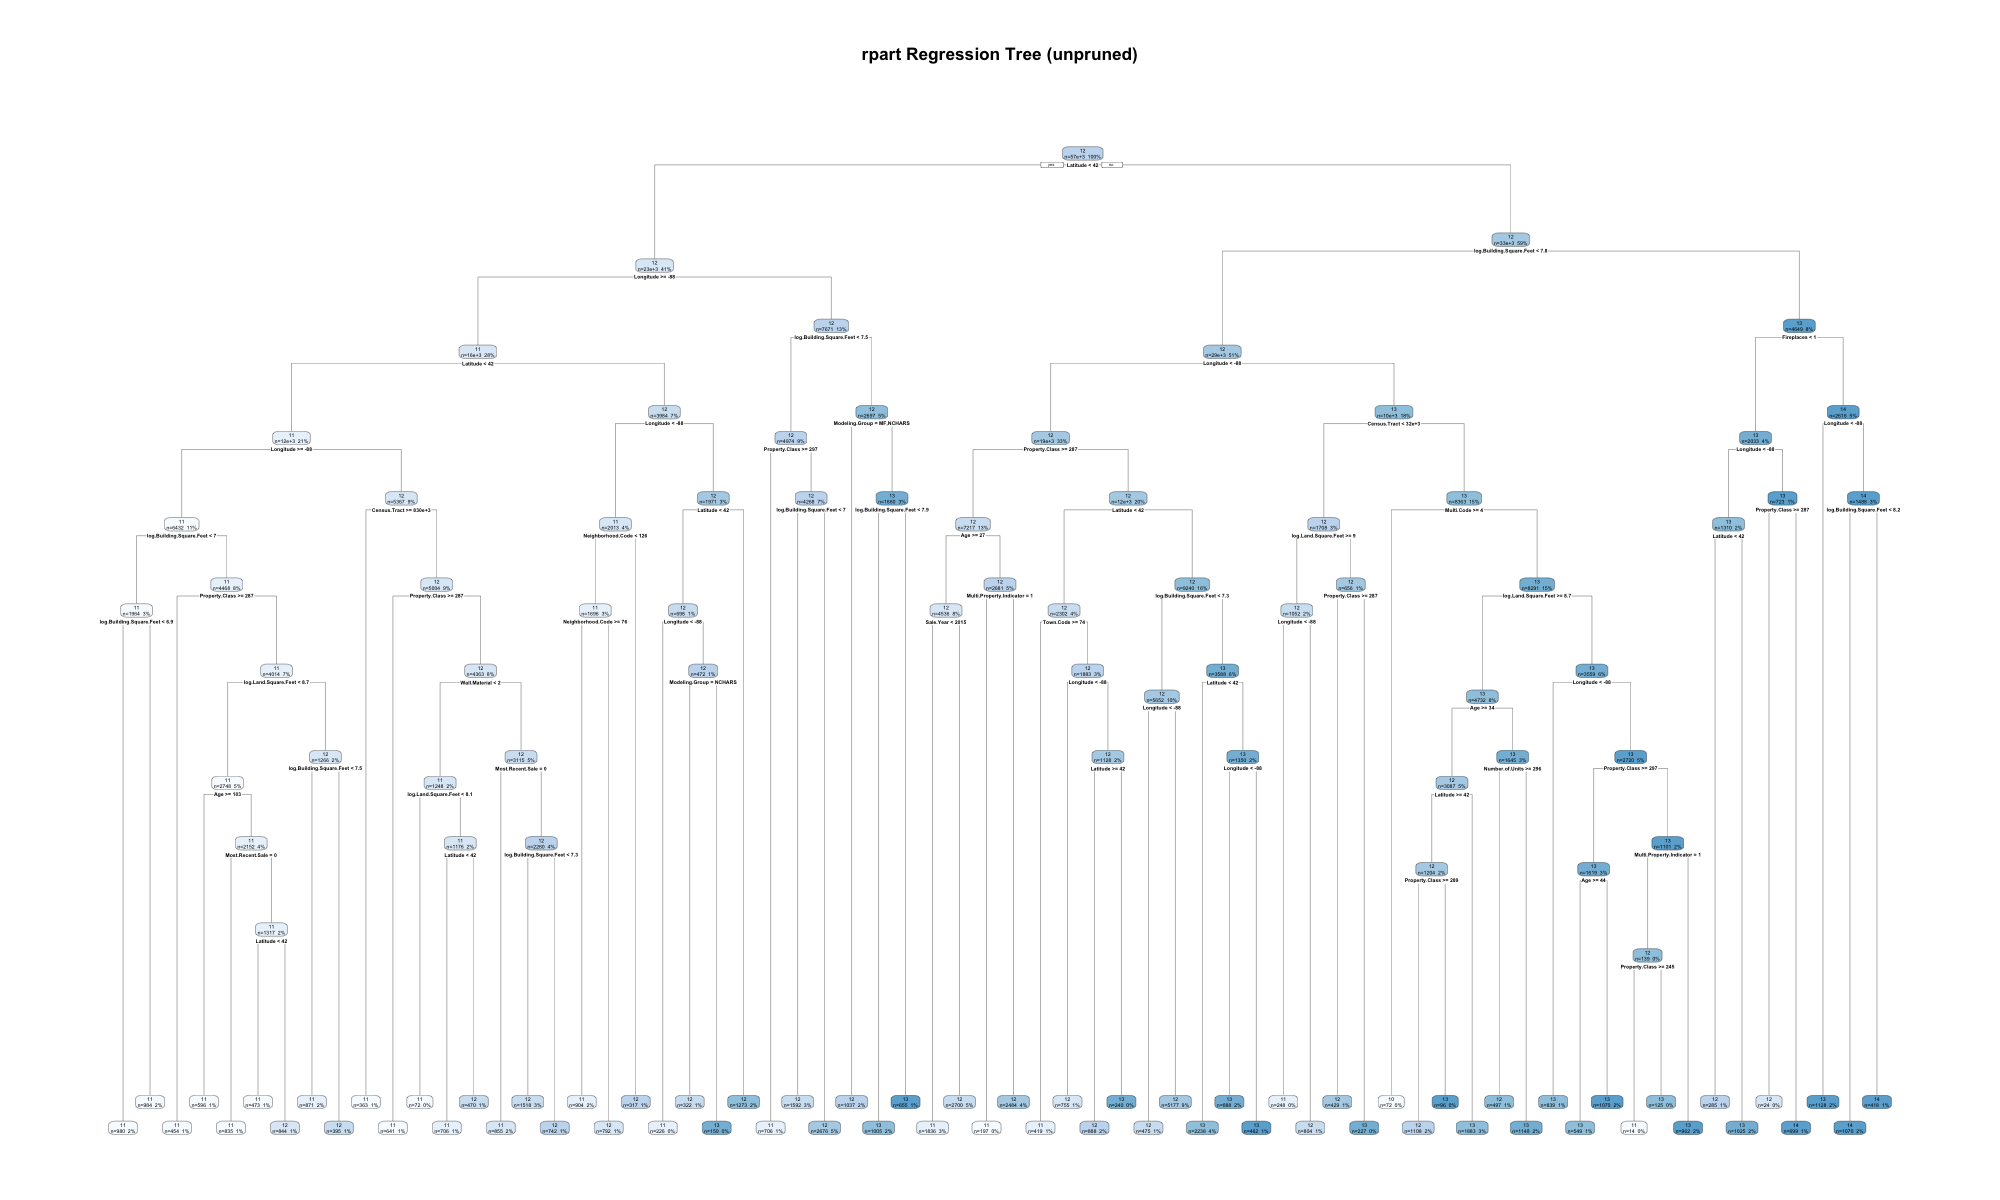

In [395]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

r_script = r'''
library(rpart)
library(rpart.plot)

train <- read.table("cook_county_train_v3.txt",
                    header = TRUE, na.strings = "NA", quote = "\"")
test  <- read.table("cook_county_test_v3.txt",
                    header = TRUE, na.strings = "NA", quote = "\"")

for (col in names(train)) {
  if (is.logical(train[[col]])) train[[col]] <- as.numeric(train[[col]])
}
for (col in names(test)) {
  if (is.logical(test[[col]])) test[[col]] <- as.numeric(test[[col]])
}

to_drop <- c("Sale.Date")
train <- train[, !(names(train) %in% to_drop)]
test  <- test[,  !(names(test)  %in% to_drop)]

cat("Train:", nrow(train), "rows x", ncol(train), "columns\n\n")
fit <- rpart(log.Sale.Price ~ .,
             data = train,
             method = "anova",
             control = rpart.control(cp = 0.001, xval = 5, minsplit = 20))

cat("Tree leaves:", sum(fit$frame$var == "<leaf>"), "\n\n")
printcp(fit)

png("rpart_tree.png", width = 2000, height = 1200, res = 130)
rpart.plot(fit, type = 2, extra = 101, fallen.leaves = TRUE,
           main = "rpart Regression Tree (unpruned)")
dev.off()

pred <- predict(fit, newdata = test)
y    <- test$log.Sale.Price
mse  <- mean((pred - y)^2)

cat("\nLog MSE: ",  round(mse, 4), "\n")
cat("Log RMSE:", round(sqrt(mse), 4), "\n")
cat("Log R²:  ", round(1 - mse / var(y), 4), "\n")
'''

Path("rpart_run.R").write_text(r_script)
result = subprocess.run(["Rscript", "rpart_run.R"], capture_output=True, text=True)

print(result.stdout)
if result.returncode != 0:
    print("---- Error ----\n", result.stderr)
else:
    display(Image("rpart_tree.png"))

### 4.2 sklearn DecisionTreeRegressor (Python CART, identical pipeline to RF / LightGBM)


Dropping 2 all-NaN columns: ['Large Lot', 'Condo Strata']
Tree leaves: 61
Tree depth:  10
Log MSE:     0.3167
Log RMSE:    0.5627
Log R²:      0.5194

Top 10 features:
 Latitude                      0.372177
Longitude                     0.228808
log Building Square Feet      0.199288
Property Class                0.051891
Total Building Square Feet    0.033296
Fireplaces                    0.020961
Census Tract                  0.013677
Age                           0.011722
Percent Ownership             0.009613
Central Air                   0.009038
dtype: float64


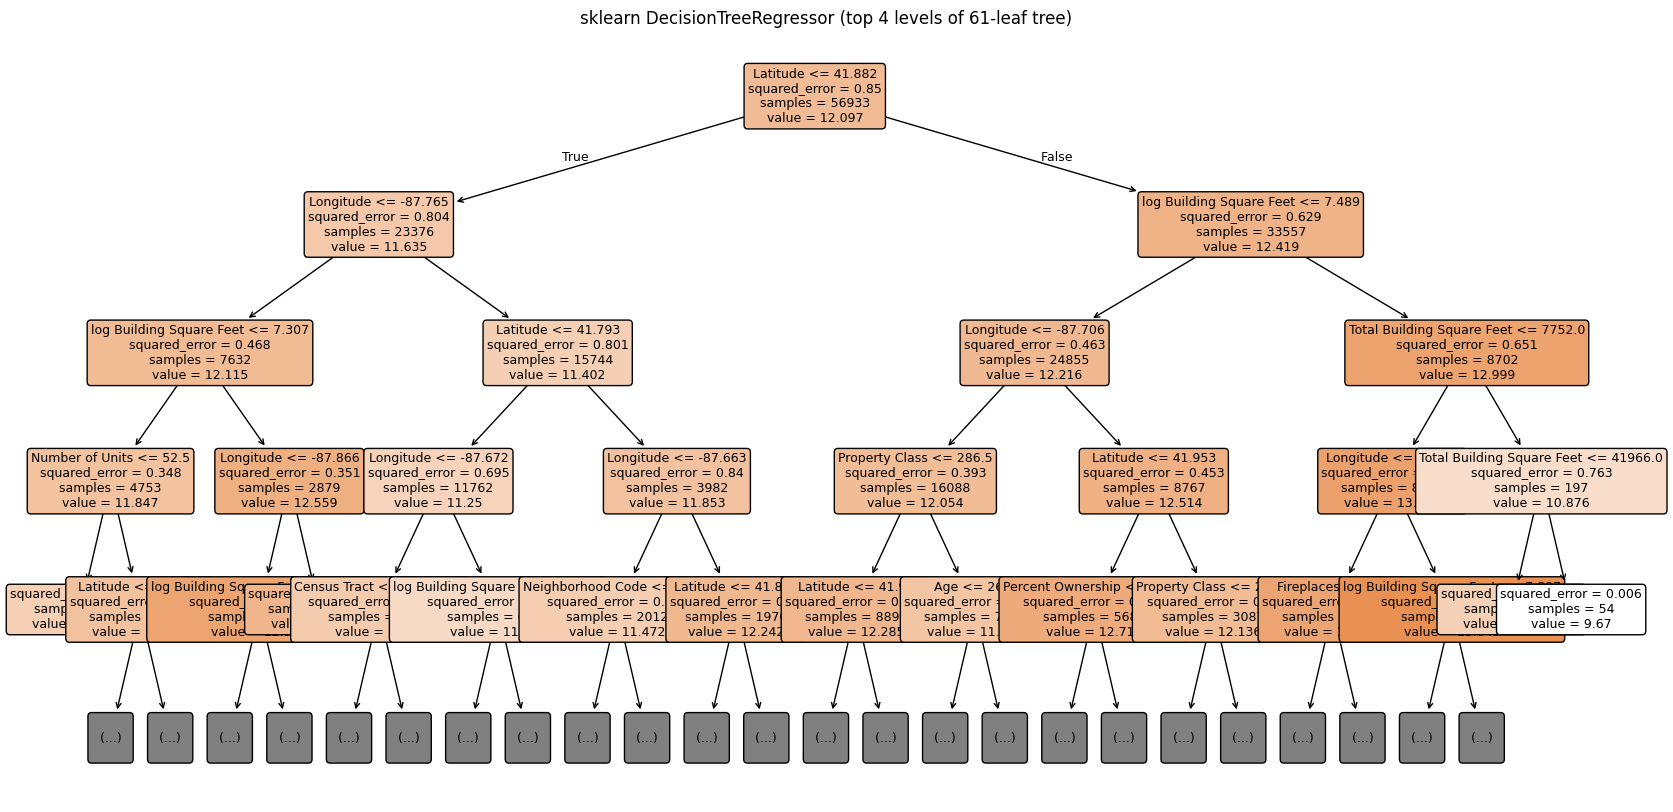

In [396]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

target = 'log Sale Price'

feature_cols = [c for c in train_df.columns
                if c != target and c != 'Sale Date']

high_card_str = [c for c in feature_cols
                 if train_df[c].dtype == object and train_df[c].nunique() > 32]
feature_cols = [c for c in feature_cols if c not in high_card_str]

all_nan = [c for c in feature_cols if train_df[c].isna().all()]
if all_nan:
    print(f"Dropping {len(all_nan)} all-NaN columns: {all_nan}")
    feature_cols = [c for c in feature_cols if c not in all_nan]

X_train = train_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

str_cols = [c for c in feature_cols if X_train[c].dtype == object]
if str_cols:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[str_cols] = enc.fit_transform(X_train[str_cols].astype(str).fillna('NA'))
    X_test[str_cols]  = enc.transform(X_test[str_cols].astype(str).fillna('NA'))

imp = SimpleImputer(strategy='median')
X_train = imp.fit_transform(X_train)
X_test  = imp.transform(X_test)

y_train = train_df[target].values
y_test  = test_df[target].values

cart = DecisionTreeRegressor(criterion='squared_error',
                             min_samples_split=20,
                             ccp_alpha=0.001,
                             random_state=0)
cart.fit(X_train, y_train)

pred = cart.predict(X_test)
mse  = ((pred - y_test) ** 2).mean()

print(f'Tree leaves: {cart.get_n_leaves()}')
print(f'Tree depth:  {cart.get_depth()}')
print(f'Log MSE:     {mse:.4f}')
print(f'Log RMSE:    {np.sqrt(mse):.4f}')
print(f'Log R²:      {1 - mse / y_test.var():.4f}')

fi = pd.Series(cart.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nTop 10 features:\n', fi.head(10))

plt.figure(figsize=(20, 10))
plot_tree(cart, max_depth=4, feature_names=feature_cols, filled=True,
          rounded=True, fontsize=9)
plt.title(f'sklearn DecisionTreeRegressor (top 4 levels of {cart.get_n_leaves()}-leaf tree)')
plt.show()

### 4.3 Why median imputation, not mean?

The numerical features we just imputed are heavily right-skewed -- the long upper tail pulls the mean above the bulk of the distribution, so mean-imputation would systematically fill missing rows with a value larger than what a typical observation looks like. The median sits inside the bulk of the distribution and is unaffected by upper-tail outliers, so it gives every imputed cell a value representative of the modal property rather than the rare large ones. The plot below makes this visible for the four most right-skewed numerical features in the training set.


/Users/induranasingh/anaconda3/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/induranasingh/anaconda3/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/induranasingh/anaconda3/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


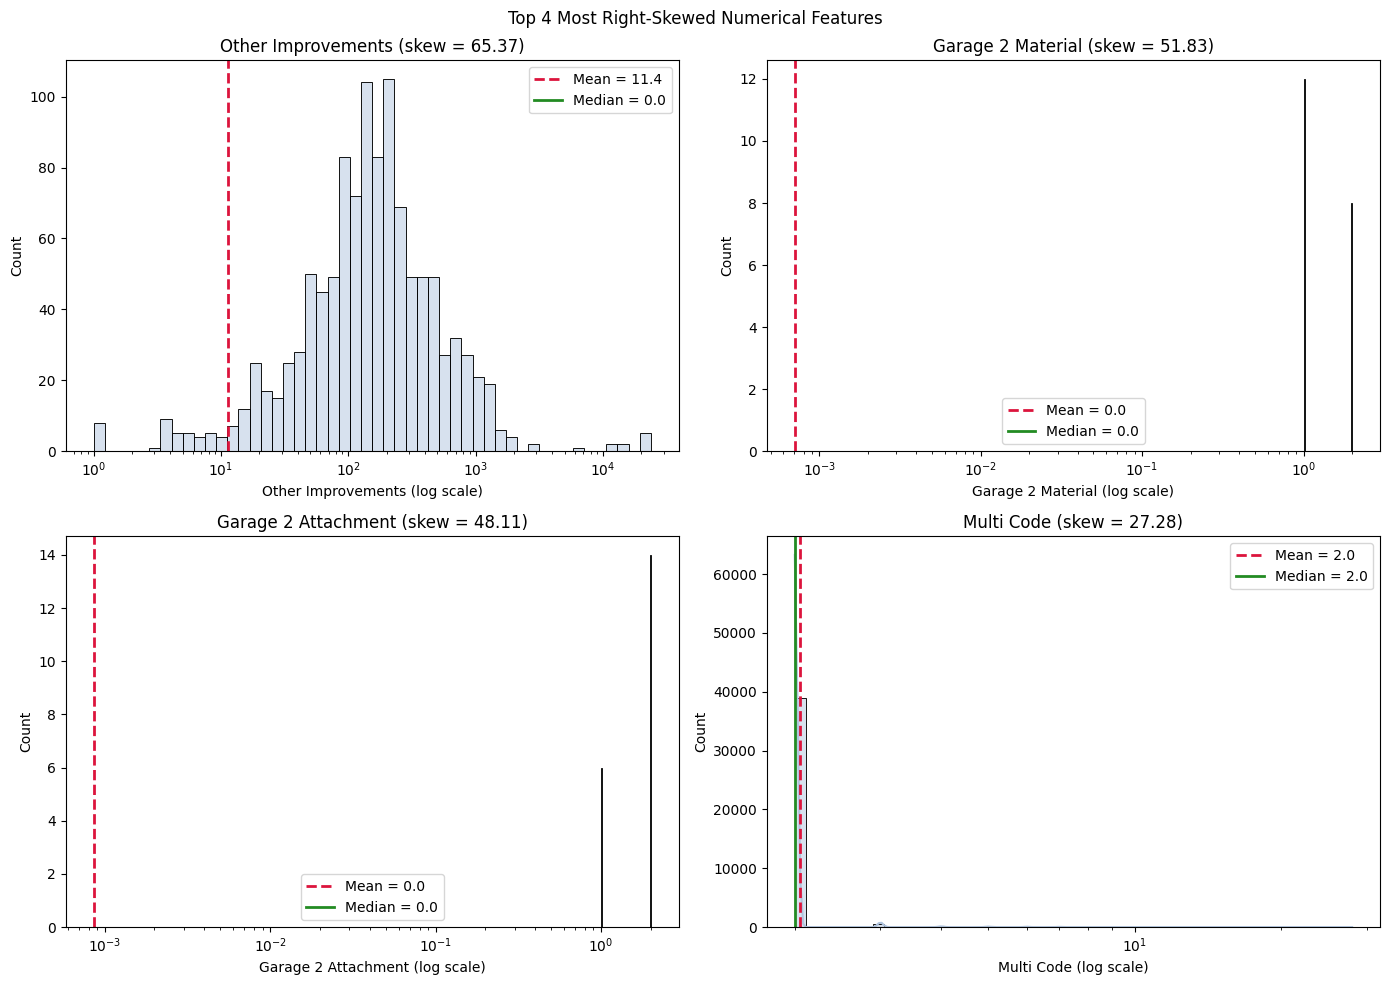

In [397]:
import seaborn as sns
import matplotlib.pyplot as plt

target = 'log Sale Price'
num_cols = [c for c in train_df.select_dtypes('number').columns if c != target]

top4 = train_df[num_cols].skew().sort_values(ascending=False).head(4).index
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(top4):
    s = train_df[col].dropna()

    if abs(s.skew()) > 1.5:
        sns.histplot(s, bins=50, kde=True, ax=axes[i], color='lightsteelblue', log_scale=True)
        axes[i].set_xlabel(f'{col} (log scale)')
    else:
        sns.histplot(s, bins=50, kde=True, ax=axes[i], color='lightsteelblue')
        axes[i].set_xlabel(col)

    axes[i].axvline(s.mean(),   color='crimson', linestyle='--', linewidth=2, label=f'Mean = {s.mean():,.1f}')
    axes[i].axvline(s.median(), color='forestgreen', linestyle='-', linewidth=2, label=f'Median = {s.median():,.1f}')

    axes[i].set_title(f'{col} (skew = {s.skew():.2f})')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Top 4 Most Right-Skewed Numerical Features')
plt.tight_layout()
plt.show()

### 4.4 Random Forest

Bagged extension of the single CART tree. Reuses the encoding/imputation pipeline from the DecisionTreeRegressor cell. Reports both held-out test metrics and free out-of-bag $R^2$.


OOB R^2 (train, free CV proxy): 0.7671
Log MSE:  0.1933
Log RMSE: 0.4396
Log R^2:  0.7067

Dollar RMSE: $       159,430
Dollar MAE : $        79,298

Top 15 features by RF importance:
Latitude                    0.173173
Longitude                   0.119898
Census Tract                0.111318
log Building Square Feet    0.072725
Town Code                   0.060650
Age                         0.050804
Fireplaces                  0.044293
log Land Square Feet        0.037851
Rooms                       0.033984
Neighborhood Code           0.032102
Full Baths                  0.026571
Property Class              0.021518
Bedrooms                    0.019058
Central Air                 0.019001
Sale Year                   0.017229


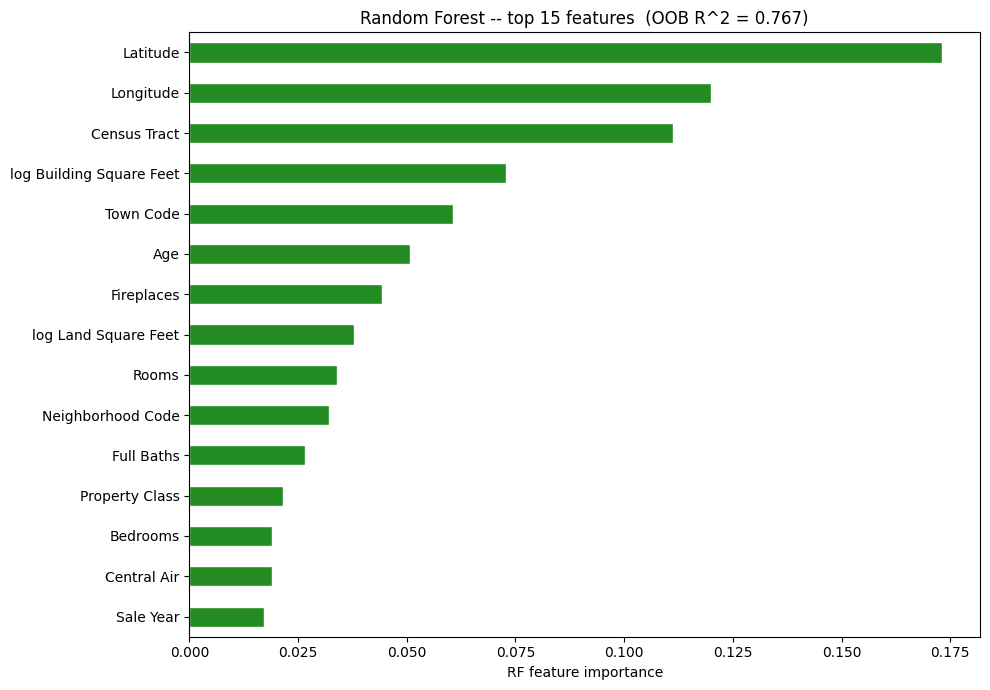

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=5,
    oob_score=True,
    n_jobs=-1,
    random_state=0,
)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
mse  = ((pred - y_test) ** 2).mean()

print(f'OOB R^2 (train, free CV proxy): {rf.oob_score_:.4f}')
print(f'Log MSE:  {mse:.4f}')
print(f'Log RMSE: {np.sqrt(mse):.4f}')
print(f'Log R^2:  {1 - mse / y_test.var():.4f}')

_obs   = np.expm1(y_test)
_pred  = np.expm1(pred)
_resid = _obs - _pred
print(f'\nDollar RMSE: ${np.sqrt((_resid**2).mean()):>14,.0f}')
print(f'Dollar MAE : ${np.abs(_resid).mean():>14,.0f}')

fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nTop 15 features by RF importance:')
print(fi.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
fi.head(15)[::-1].plot.barh(ax=ax, color='forestgreen', edgecolor='white')
ax.set_xlabel('RF feature importance')
ax.set_title(f'Random Forest -- top 15 features  (OOB R^2 = {rf.oob_score_:.3f})')
plt.tight_layout()
plt.show()


### 4.5 LightGBM (gradient boosting)

Leaf-wise gradient-boosted trees with early stopping on a 20% validation slice held out from the training set. Reuses the same encoding/imputation pipeline as RF. Sanitises feature names because LightGBM rejects JSON-special characters.


Training until validation scores don't improve for 100 rounds
[200]	train's rmse: 0.408076	val's rmse: 0.424768
[400]	train's rmse: 0.370805	val's rmse: 0.403135
[600]	train's rmse: 0.348842	val's rmse: 0.395388
[800]	train's rmse: 0.3315	val's rmse: 0.390612
[1000]	train's rmse: 0.317631	val's rmse: 0.387868
[1200]	train's rmse: 0.305324	val's rmse: 0.386433
[1400]	train's rmse: 0.294692	val's rmse: 0.384896
[1600]	train's rmse: 0.284843	val's rmse: 0.384129
[1800]	train's rmse: 0.276177	val's rmse: 0.383608
[2000]	train's rmse: 0.268141	val's rmse: 0.383292
[2200]	train's rmse: 0.260568	val's rmse: 0.383032
Early stopping, best iteration is:
[2150]	train's rmse: 0.262378	val's rmse: 0.382982

Best iteration: 2150
Log MSE:  0.1570
Log RMSE: 0.3963
Log R^2:  0.7617

Dollar RMSE: $       124,703
Dollar MAE : $        64,601

Top 15 features by LightGBM gain:
Latitude                    62018.379837
Longitude                   48094.097142
log Building Square Feet    34653.803617
Census 

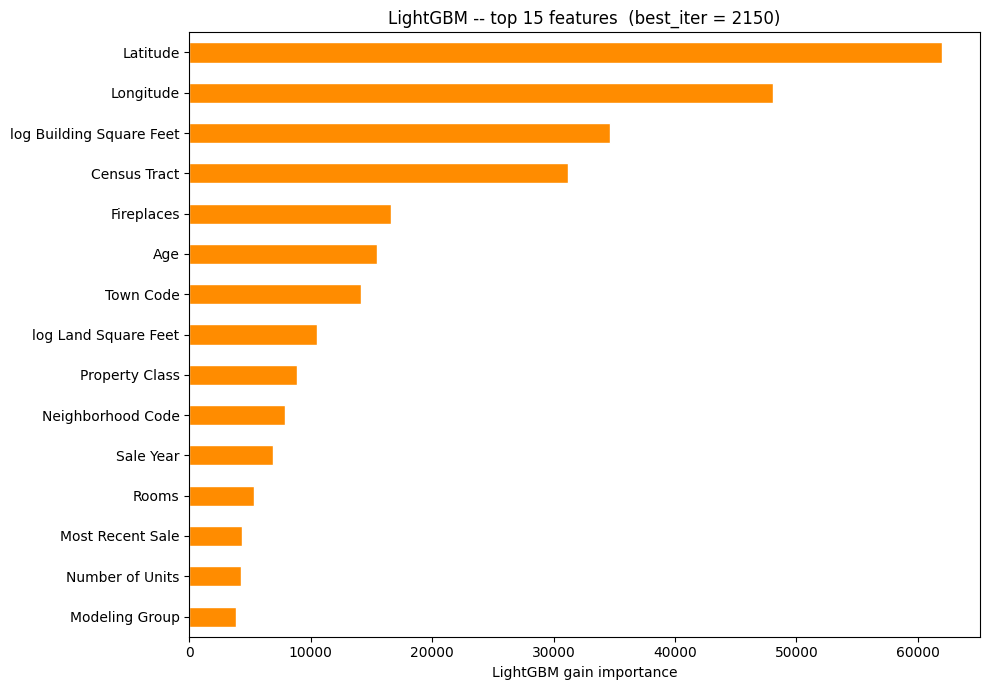

In [399]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import re
feature_cols_lgb = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in feature_cols]

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

lgbtrain = lgb.Dataset(X_tr,  label=y_tr,  feature_name=feature_cols_lgb)
lgbval   = lgb.Dataset(X_val, label=y_val, feature_name=feature_cols_lgb, reference=lgbtrain)

lgb_params = {
    'objective':        'regression',
    'metric':           'rmse',
    'num_leaves':       31,
    'learning_rate':    0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'min_data_in_leaf': 20,
    'max_depth':        -1,
    'verbose':          -1,
    'nthread':          -1,
}

model = lgb.train(
    lgb_params,
    lgbtrain,
    num_boost_round = 6000,
    valid_sets      = [lgbtrain, lgbval],
    valid_names     = ['train', 'val'],
    callbacks       = [lgb.early_stopping(100), lgb.log_evaluation(200)],
)

print(f'\nBest iteration: {model.best_iteration}')

test_preds = model.predict(X_test, num_iteration=model.best_iteration)

mse = ((test_preds - y_test) ** 2).mean()
print(f'Log MSE:  {mse:.4f}')
print(f'Log RMSE: {np.sqrt(mse):.4f}')
print(f'Log R^2:  {1 - mse / y_test.var():.4f}')

_obs, _pred = np.expm1(y_test), np.expm1(test_preds)
_resid = _obs - _pred
print(f'\nDollar RMSE: ${np.sqrt((_resid**2).mean()):>14,.0f}')
print(f'Dollar MAE : ${np.abs(_resid).mean():>14,.0f}')

fi = pd.Series(model.feature_importance(importance_type='gain'),
               index=feature_cols).sort_values(ascending=False)
print('\nTop 15 features by LightGBM gain:')
print(fi.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
fi.head(15)[::-1].plot.barh(ax=ax, color='darkorange', edgecolor='white')
ax.set_xlabel('LightGBM gain importance')
ax.set_title(f'LightGBM -- top 15 features  (best_iter = {model.best_iteration})')
plt.tight_layout()
plt.show()